# Urban Expansion vs Economic Activity: A Multimodal Deep Learning Approach

**Course:** AC209b / CS1090b — Advanced Data Science  
**Canvas Group Number:** 12  
**Members:** Minh Tran, Jenny Zhu, Cathy Liu, Maddy Jin  
**GitHub:** https://github.com/cathyliu0510/209b_Final_Project

---

## Research Question

Can a multimodal deep learning model that jointly encodes satellite imagery and economic time series into a shared latent space reveal meaningful structure in how U.S. Sun Belt cities grow — and detect when that structure breaks down?

---

## Project Overview

This notebook implements a four-stage multimodal deep learning pipeline across 14 Sun Belt metros from 2013–2023. Each stage is self-contained with its own training loop, evaluation, and saved checkpoint.

| Stage | Model | Purpose |
|-------|-------|---------|
| 1 | ResNet-18 (partial fine-tune) | Learn urban-aware image embeddings supervised by GHSL masks |
| 2 | LSTM Sequence Autoencoder | Learn compressed representations of economic time series |
| 3 | Multimodal VAE + Contrastive Loss | Align image and economic embeddings in a shared latent space |
| 4 | Persistent Homology (TDA) | Characterize topological structure of the learned latent space |

**Outside-class contributions:**
- CLIP-style cross-modal contrastive alignment (InfoNCE loss) applied to satellite + economic modalities
- Persistent homology via `ripser` on the VAE latent space to detect topological structure and COVID-era anomalies

---

## Table of Contents

1. [Setup & Dependencies](#1-setup--dependencies)
2. [Configuration & Reproducibility](#2-configuration--reproducibility)
3. [Data Loading & Verification](#3-data-loading--verification)
4. [Stage 1 — CNN Image Encoder](#4-stage-1--cnn-image-encoder)
5. [Stage 2 — LSTM Sequence Autoencoder](#5-stage-2--lstm-sequence-autoencoder)
6. [Stage 3 — Multimodal VAE with Contrastive Alignment](#6-stage-3--multimodal-vae-with-contrastive-alignment)
7. [Analysis & Results](#7-analysis--results)
8. [Stage 4 — Persistent Homology](#8-stage-4--persistent-homology)
9. [Discussion & Limitations](#9-discussion--limitations)

---
## 1. Setup & Dependencies

All dependencies are pinned for reproducibility. Training runs on Apple Silicon (MPS) locally. Pre-saved checkpoints are provided so the grader can run the full notebook without retraining by keeping all `RETRAIN` flags set to `False`.

**Expected data layout relative to this notebook:**
```
data/
  imagery/{metro}/modis_rgb/{year}.tif
  imagery/{metro}/viirs_night/{year}.tif
  ghsl/{metro}/{epoch}.tif
  tensors/{metro}_stack.npz
  modeling/panel_features.csv
checkpoints/
  cnn_encoder.pt
  lstm_autoencoder.pt
  multimodal_vae.pt
```

In [1]:
import torch
import gc
gc.collect()
torch.mps.empty_cache() if torch.backends.mps.is_available() else None
print("memory cleared")

memory cleared


In [2]:
import os
import json
import warnings
import random
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision.models import ResNet18_Weights

warnings.filterwarnings("ignore")

print("imports ok")
print(f"torch        : {torch.__version__}")
print(f"numpy        : {np.__version__}")
print(f"pandas       : {pd.__version__}")

imports ok
torch        : 2.2.2
numpy        : 2.2.6
pandas       : 2.3.3


In [3]:
# ── Device ───────────────────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"device : {device}")

device : mps


---
## 2. Configuration & Reproducibility

All random seeds are fixed globally. All file paths are relative to the notebook root. The three `RETRAIN_*` flags control whether each stage trains from scratch or loads a pre-saved checkpoint. Set all to `False` for a fast grading run.

In [4]:
# ── Seed everything for full reproducibility ──────────────────────────────────
SEED = 42

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f"global seed : {SEED}")

global seed : 42


In [5]:
# ── Paths (all relative to notebook root) ────────────────────────────────────
ROOT        = Path(".")
IMAGERY_DIR = ROOT / "data" / "imagery"
TENSOR_DIR  = ROOT / "data" / "tensors"
GHSL_DIR    = ROOT / "data" / "ghsl"
ECON_PATH   = ROOT / "data" / "modeling" / "panel_features.csv"
CKPT_DIR    = ROOT / "checkpoints"
CKPT_DIR.mkdir(exist_ok=True)

# ── Metros ────────────────────────────────────────────────────────────────────
METROS = [
    "atlanta", "austin", "charlotte", "dallas", "denver", "houston",
    "jacksonville", "las_vegas", "nashville", "orlando", "phoenix",
    "raleigh", "san_antonio", "tampa",
]

# ── Year ranges ───────────────────────────────────────────────────────────────
MODIS_YEARS = list(range(2013, 2024))   # 11 years
VIIRS_YEARS = list(range(2017, 2024))   #  7 years
GHSL_EPOCHS = [2000, 2005, 2010, 2015, 2020]

TRAIN_YEARS = list(range(2013, 2019))   # 2013–2018
VAL_YEARS   = [2019, 2020]              # 2019–2020
TEST_YEARS  = list(range(2021, 2024))   # 2021–2023

# ── Retrain flags ─────────────────────────────────────────────────────────────
# False = load checkpoint (fast, for grading)
# True  = train from scratch
RETRAIN_CNN  = False
RETRAIN_LSTM = False
RETRAIN_VAE  = False

print("config ok")
print(f"metros       : {len(METROS)}")
print(f"MODIS years  : {MODIS_YEARS[0]}–{MODIS_YEARS[-1]}  ({len(MODIS_YEARS)} years)")
print(f"GHSL epochs  : {GHSL_EPOCHS}")
print(f"checkpoints  : {CKPT_DIR.resolve()}")
print(f"RETRAIN      : CNN={RETRAIN_CNN}  LSTM={RETRAIN_LSTM}  VAE={RETRAIN_VAE}")

config ok
metros       : 14
MODIS years  : 2013–2023  (11 years)
GHSL epochs  : [2000, 2005, 2010, 2015, 2020]
checkpoints  : /Users/robintran/Desktop/APCOMP209B/209b_Final_Project/checkpoints
RETRAIN      : CNN=False  LSTM=False  VAE=False


---
## 3. Data Loading & Verification

Before any modeling we verify all expected files are present and inspect one sample from each data source. This section loads:
- MODIS 4-channel tensors (RGB + VIIRS stacked, shape `(T, H, W, 4)`)
- GHSL binary masks (shape `(H, W)`, values 0/1)
- Economic panel (`panel_features.csv`, 126 rows)

We also confirm that the MODIS spatial grid and GHSL masks are already aligned — this was handled in the preprocessing notebooks `02b_ghsl_processing` and `03_raster_preprocessing`.

In [6]:
# ── Verify all expected MODIS and VIIRS tifs exist ───────────────────────────
missing, present = [], []

for metro in METROS:
    for year in MODIS_YEARS:
        p = IMAGERY_DIR / metro / "modis_rgb" / f"{year}.tif"
        (present if p.exists() else missing).append(str(p))
    for year in VIIRS_YEARS:
        p = IMAGERY_DIR / metro / "viirs_night" / f"{year}.tif"
        (present if p.exists() else missing).append(str(p))

print(f"imagery files present : {len(present)}")
print(f"imagery files missing : {len(missing)}")
if missing:
    for f in missing[:10]:
        print(f"  MISSING: {f}")

imagery files present : 252
imagery files missing : 0


In [7]:
# ── Verify all expected GHSL masks exist ─────────────────────────────────────
ghsl_missing, ghsl_present = [], []

for metro in METROS:
    for epoch in GHSL_EPOCHS:
        p = GHSL_DIR / metro / f"{epoch}.tif"
        (ghsl_present if p.exists() else ghsl_missing).append(str(p))

print(f"GHSL masks present : {len(ghsl_present)}  (expected 70)")
print(f"GHSL masks missing : {len(ghsl_missing)}")
if ghsl_missing:
    for f in ghsl_missing:
        print(f"  MISSING: {f}")

GHSL masks present : 70  (expected 70)
GHSL masks missing : 0


In [8]:
# ── Verify economic panel ─────────────────────────────────────────────────────
assert ECON_PATH.exists(), f"Economic panel not found at {ECON_PATH}"

econ_df = pd.read_csv(ECON_PATH)
print(f"economic panel shape : {econ_df.shape}")
print(f"columns              : {list(econ_df.columns[:8])} ...")
print(f"metros               : {sorted(econ_df['metro'].unique())}")
print(f"years                : {sorted(econ_df['year'].unique())}")

economic panel shape : (140, 47)
columns              : ['year', 'metro', 'gdp_millions', 'unemployment_rate', 'employment_thousands', 'total_permits', 'interpolated', 'modis_red_mean'] ...
metros               : ['atlanta', 'austin', 'charlotte', 'dallas', 'denver', 'houston', 'jacksonville', 'las_vegas', 'nashville', 'orlando', 'phoenix', 'raleigh', 'san_antonio', 'tampa']
years                : [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023)]


In [9]:
# ── Inspect one MODIS image and its corresponding GHSL mask ──────────────────

sample_metro = "houston"
sample_year  = 2015
sample_epoch = 2015 

modis_path = IMAGERY_DIR / sample_metro / "modis_rgb" / f"{sample_year}.tif"
ghsl_path  = GHSL_DIR / sample_metro / f"{sample_epoch}.tif"

with rasterio.open(modis_path) as src:
    modis_arr = src.read()                        # (3, H, W) uint8
    modis_rgb = np.transpose(modis_arr, (1,2,0))  # (H, W, 3)

with rasterio.open(ghsl_path) as src:
    ghsl_mask = src.read(1)                       # (H, W) uint8, values 0/1

print(f"MODIS shape  : {modis_rgb.shape}  dtype={modis_rgb.dtype}")
print(f"GHSL shape   : {ghsl_mask.shape}  dtype={ghsl_mask.dtype}")
print(f"GHSL values  : {np.unique(ghsl_mask)}  built-up pixels={ghsl_mask.sum()}")
print(f"Spatial match: {modis_rgb.shape[:2] == ghsl_mask.shape}")

MODIS shape  : (512, 512, 3)  dtype=uint8
GHSL shape   : (512, 512)  dtype=uint8
GHSL values  : [0 1]  built-up pixels=165258
Spatial match: True


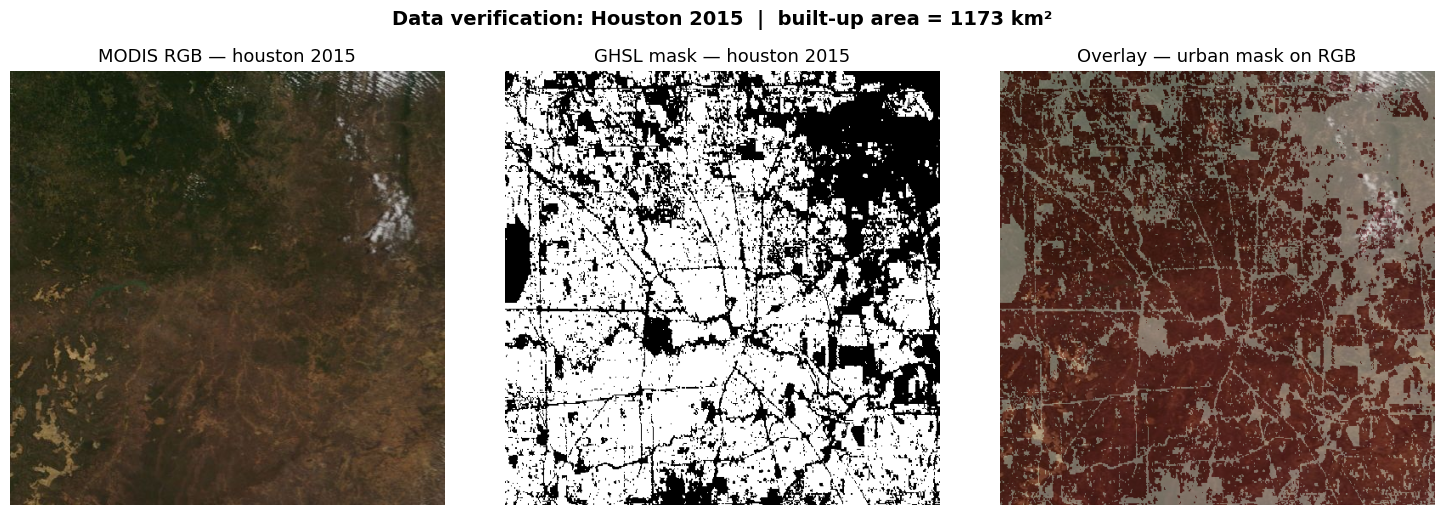

In [10]:
# ── Visualize MODIS image alongside GHSL mask ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# MODIS RGB
axes[0].imshow(modis_rgb)
axes[0].set_title(f"MODIS RGB — {sample_metro} {sample_year}", fontsize=13)
axes[0].axis("off")

# GHSL binary mask
axes[1].imshow(ghsl_mask, cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"GHSL mask — {sample_metro} {sample_epoch}", fontsize=13)
axes[1].axis("off")

# Overlay — MODIS with mask boundary in red
overlay = modis_rgb.copy().astype(np.float32) / 255.0
axes[2].imshow(overlay)
axes[2].imshow(ghsl_mask, cmap="Reds", alpha=0.35, vmin=0, vmax=1)
axes[2].set_title("Overlay — urban mask on RGB", fontsize=13)
axes[2].axis("off")

plt.suptitle(
    f"Data verification: {sample_metro.title()} {sample_year}  |  "
    f"built-up area = {ghsl_mask.sum() * 0.0071:.0f} km²",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("figures/00_data_verification.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

---
## 4. Stage 1 - CNN Image Encoder

We fine-tune a ResNet-18 to extract urban-aware image embeddings
from MODIS 4-channel imagery (RGB + VIIRS night-lights).

### Design decisions

**Patch-level training:** each image is divided into non-overlapping 128×128
patches. This converts 42 city-epoch pairs into ~1,600+ training patches,
enables proper mini-batch training, and forces the model to learn local
urban texture rather than global city layout — consistent with how remote
sensing CNNs are trained in published literature.

**Training pairs:** GHSL epochs 2010, 2015 overlap with MODIS coverage.
We use MODIS 2013 as a proxy for GHSL 2010 (3-year gap, minimal urban change),
MODIS 2015 for GHSL 2015, and hold out MODIS 2020 / GHSL 2020 for validation.
Train: 28 city-epoch pairs → ~1,100 patches. Val: 14 pairs → ~560 patches.

**Loss:** BCE + Dice combined. BCE alone suffers from class imbalance
(most pixels are non-urban). Dice loss directly optimizes overlap and is
robust to imbalance.

**Partial fine-tuning:** ResNet-18 layers 1–2 frozen (low-level edge/texture
features transfer from ImageNet). Layers 3–4 unfrozen and updated with GHSL
loss, steering them toward urban-relevant semantic features.

**VIIRS 4th channel:** initialized as the mean of pretrained RGB weights —
standard practice for adding channels to pretrained convnets.

**Validation:** IoU and Dice score on held-out 2020 masks (temporal holdout).
Note: every city appears in both train and val — this tests temporal
generalization, not city generalization. We acknowledge this as a scope
limitation given only 14 cities.

**Embedding validation:** we compare frozen ImageNet ResNet-18 embeddings vs
GHSL-fine-tuned embeddings using a linear probe: Ridge regression predicting
GHSL urban fraction from the 512-dim embedding. Higher R² for fine-tuned
embeddings is direct evidence that GHSL supervision improved urban
representation quality.

In [11]:
# ── Data augmentation transforms ──────────────────────────────────────────────
# Applied to MODIS RGB channels only.

import random
from torchvision import transforms

def augment_patch(img_patch, mask_patch):
    """
    img_patch  : (4, H, W) float32 tensor
    mask_patch : (1, H, W) float32 tensor
    Returns augmented (img, mask) with consistent geometric transforms.
    """
    # Random horizontal flip
    if random.random() > 0.5:
        img_patch  = torch.flip(img_patch,  dims=[2])
        mask_patch = torch.flip(mask_patch, dims=[2])

    # Random vertical flip
    if random.random() > 0.5:
        img_patch  = torch.flip(img_patch,  dims=[1])
        mask_patch = torch.flip(mask_patch, dims=[1])

    # Random 90-degree rotation
    k = random.randint(0, 3)
    img_patch  = torch.rot90(img_patch,  k, dims=[1, 2])
    mask_patch = torch.rot90(mask_patch, k, dims=[1, 2])

    # Color jitter on RGB channels only (not VIIRS, not mask)
    if random.random() > 0.5:
        brightness = random.uniform(0.8, 1.2)
        img_patch[:3] = (img_patch[:3] * brightness).clamp(0, 1)

    if random.random() > 0.5:
        contrast_factor = random.uniform(0.8, 1.2)
        mean = img_patch[:3].mean()
        img_patch[:3] = ((img_patch[:3] - mean) * contrast_factor + mean).clamp(0, 1)

    return img_patch, mask_patch

In [12]:
from pathlib import Path

class GHSLPatchDataset(Dataset):
    """
    Lazy-loading patch dataset.
    Stores only file paths and patch coordinates during __init__.
    Loads each patch from disk on demand in __getitem__.
    RAM usage is constant regardless of dataset size.
    """

    def __init__(self, metros, epoch_modis_pairs, imagery_dir, ghsl_dir,
                 viirs_years, patch_size=128, augment=False, bg_drop_rate=0.5):
        self.patch_size  = patch_size
        self.augment     = augment
        self.viirs_years = viirs_years
        self.imagery_dir = imagery_dir
        self.index       = []

        for metro in tqdm(metros, desc="indexing patches"):
            for ghsl_epoch, modis_year in epoch_modis_pairs:
                modis_path = imagery_dir / metro / "modis_rgb" / f"{modis_year}.tif"
                ghsl_path  = ghsl_dir   / metro / f"{ghsl_epoch}.tif"

                if not modis_path.exists() or not ghsl_path.exists():
                    continue

                with rasterio.open(modis_path) as src:
                    H, W = src.height, src.width

                with rasterio.open(ghsl_path) as src:
                    mask_full = src.read(1).astype(np.float32)

                ps = patch_size
                for r in range(0, H - ps + 1, ps):
                    for c in range(0, W - ps + 1, ps):
                        mask_p     = mask_full[r:r+ps, c:c+ps]
                        urban_frac = mask_p.mean()
                        if urban_frac == 0.0 and random.random() < bg_drop_rate:
                            continue
                        self.index.append((
                            metro, ghsl_epoch, modis_year,
                            str(modis_path), str(ghsl_path), r, c
                        ))
                del mask_full

        print(f"  total patches : {len(self.index)}")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        metro, ghsl_epoch, modis_year, modis_path, ghsl_path, r, c = self.index[idx]
        ps = self.patch_size

        with rasterio.open(modis_path) as src:
            rgb = src.read(
                window=rasterio.windows.Window(c, r, ps, ps)
            ).astype(np.float32) / 255.0

        viirs_path = self.imagery_dir / metro / "viirs_night" / f"{modis_year}.tif"

        if viirs_path.exists() and modis_year >= min(self.viirs_years):
            with rasterio.open(str(viirs_path)) as src:
                viirs_full = src.read(1).astype(np.float32)
            nz = viirs_full[viirs_full > 0]
            if len(nz):
                viirs_full = np.clip(
                    (viirs_full - np.percentile(nz, 1)) /
                    (np.percentile(nz, 99) - np.percentile(nz, 1) + 1e-8),
                    0, 1)
            else:
                viirs_full = np.zeros_like(viirs_full)
            fh, fw = viirs_full.shape
            if fh >= ps and fw >= ps:
                r_v = min(r, fh - ps)
                c_v = min(c, fw - ps)
                viirs = viirs_full[r_v:r_v+ps, c_v:c_v+ps]
            else:
                viirs_t = torch.tensor(viirs_full).unsqueeze(0).unsqueeze(0)
                viirs   = F.interpolate(
                    viirs_t, size=(ps, ps),
                    mode="bilinear", align_corners=False
                ).squeeze().numpy()
        else:
            viirs = np.zeros((ps, ps), dtype=np.float32)

        img  = np.concatenate([rgb, viirs[np.newaxis]], axis=0).astype(np.float32)

        with rasterio.open(ghsl_path) as src:
            mask = src.read(
                1, window=rasterio.windows.Window(c, r, ps, ps)
            ).astype(np.float32)

        img_t  = torch.tensor(img,  dtype=torch.float32)
        mask_t = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        if self.augment:
            img_t, mask_t = augment_patch(img_t, mask_t)

        return img_t, mask_t, metro, ghsl_epoch


print("Building training patch dataset...")
train_patch_ds = GHSLPatchDataset(
    metros=METROS,
    epoch_modis_pairs=[(2010, 2013), (2015, 2015)],
    imagery_dir=IMAGERY_DIR,
    ghsl_dir=GHSL_DIR,
    viirs_years=VIIRS_YEARS,
    patch_size=128,
    augment=True,
    bg_drop_rate=0.5,
)

print("Building validation patch dataset...")
val_patch_ds = GHSLPatchDataset(
    metros=METROS,
    epoch_modis_pairs=[(2020, 2020)],
    imagery_dir=IMAGERY_DIR,
    ghsl_dir=GHSL_DIR,
    viirs_years=VIIRS_YEARS,
    patch_size=128,
    augment=False,
    bg_drop_rate=0.0,
)

train_patch_loader = DataLoader(train_patch_ds, batch_size=16,
                                shuffle=True,  num_workers=0, pin_memory=False)
val_patch_loader   = DataLoader(val_patch_ds,   batch_size=16,
                                shuffle=False, num_workers=0, pin_memory=False)

print(f"\ntrain patches : {len(train_patch_ds)}")
print(f"val patches   : {len(val_patch_ds)}")
print(f"train batches : {len(train_patch_loader)}")
print(f"val batches   : {len(val_patch_loader)}")

Building training patch dataset...


indexing patches: 100%|██████████| 14/14 [00:00<00:00, 139.95it/s]


  total patches : 701
Building validation patch dataset...


indexing patches: 100%|██████████| 14/14 [00:00<00:00, 349.53it/s]

  total patches : 352

train patches : 701
val patches   : 352
train batches : 44
val batches   : 22


In [13]:
# ── Loss functions ────────────────────────────────────────────────────────────

def dice_loss(pred_logits, target_mask, smooth=1.0):
    """
    Soft Dice loss for binary segmentation.
    """
    pred_prob = torch.sigmoid(pred_logits)
    pred_flat = pred_prob.view(pred_prob.size(0), -1)
    targ_flat = target_mask.view(target_mask.size(0), -1)
    intersection = (pred_flat * targ_flat).sum(dim=1)
    dice = (2.0 * intersection + smooth) / (
        pred_flat.sum(dim=1) + targ_flat.sum(dim=1) + smooth
    )
    return 1.0 - dice.mean()


def combined_loss(pred_logits, target_mask, bce_weight=0.5):
    """
    BCE + Dice combined loss.
    """
    bce  = F.binary_cross_entropy_with_logits(pred_logits, target_mask)
    dice = dice_loss(pred_logits, target_mask)
    return bce_weight * bce + (1.0 - bce_weight) * dice


def compute_iou(pred_logits, target_mask, threshold=0.5):
    """
    IoU for binary segmentation.
    """
    pred_bin  = (torch.sigmoid(pred_logits) > threshold).float()
    target    = target_mask.float()
    intersection = (pred_bin * target).sum(dim=(1,2,3))
    union        = (pred_bin + target).clamp(max=1).sum(dim=(1,2,3))
    return ((intersection + 1e-6) / (union + 1e-6)).mean().item()


def compute_dice(pred_logits, target_mask, threshold=0.5):
    """
    Dice coefficient (F1 score) for binary segmentation.
    """
    pred_bin  = (torch.sigmoid(pred_logits) > threshold).float()
    target    = target_mask.float()
    pred_flat = pred_bin.view(pred_bin.size(0), -1)
    targ_flat = target.view(target.size(0), -1)
    intersection = (pred_flat * targ_flat).sum(dim=1)
    dice = (2.0 * intersection + 1e-6) / (
        pred_flat.sum(dim=1) + targ_flat.sum(dim=1) + 1e-6
    )
    return dice.mean().item()

In [14]:
# ── CNN model: ResNet-18 with 4-channel input + segmentation head ─────────────
from torchvision.models import resnet18, ResNet18_Weights
_ = resnet18(weights=ResNet18_Weights.DEFAULT)
print("weights downloaded")
class CNNEncoder(nn.Module):
    """
    ResNet-18 backbone modified for 4-channel MODIS+VIIRS input.

    Architecture:
    - Stem + layers 1-2: FROZEN (ImageNet low-level features)
    - Layers 3-4: UNFROZEN, fine-tuned with GHSL segmentation loss
    - Segmentation head: 5× ConvTranspose2d, upsamples 32× back to input size
    - Embedding: 512-dim global average pool of layer4 output

    The segmentation head is used only during training.
    At inference time, extract_embedding() bypasses it entirely.
    """

    def __init__(self, freeze_layers=(1, 2)):
        super().__init__()

        backbone = models.resnet18(weights=ResNet18_Weights.DEFAULT)

        # Modify conv1 to accept 4 channels
        old_conv = backbone.conv1
        new_conv = nn.Conv2d(4, 64, kernel_size=7, stride=2,
                             padding=3, bias=False)
        with torch.no_grad():
            new_conv.weight[:, :3] = old_conv.weight
            new_conv.weight[:, 3]  = old_conv.weight.mean(dim=1)
        backbone.conv1 = new_conv

        # Backbone
        self.stem   = nn.Sequential(backbone.conv1, backbone.bn1,
                                    backbone.relu, backbone.maxpool)
        self.layer1 = backbone.layer1   
        self.layer2 = backbone.layer2  
        self.layer3 = backbone.layer3   
        self.layer4 = backbone.layer4   
        self.gap    = nn.AdaptiveAvgPool2d(1)

        # Freeze specified layers
        layers_to_freeze = [self.stem]
        if 1 in freeze_layers: layers_to_freeze.append(self.layer1)
        if 2 in freeze_layers: layers_to_freeze.append(self.layer2)
        for module in layers_to_freeze:
            for p in module.parameters():
                p.requires_grad = False

        # Segmentation head: 5× upsample by 2 = 32× total
        self.seg_head = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, stride=2, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128,  64, 4, stride=2, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.ConvTranspose2d( 64,  32, 4, stride=2, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.ConvTranspose2d( 32,   1, 4, stride=2, padding=1),
        )

        self.dropout = nn.Dropout2d(p=0.2)

    def forward(self, x):
        """
        x : (B, 4, H, W)
        Returns logits (B,1,H,W) and embedding (B,512).
        """
        f = self.stem(x)
        f = self.layer1(f)
        f = self.layer2(f)
        f = self.layer3(f)
        f = self.dropout(f)
        f = self.layer4(f)                                 
        embedding = self.gap(f).flatten(1)                  
        logits    = self.seg_head(f)                         
        logits    = F.interpolate(logits, size=x.shape[2:],
                                  mode="bilinear", align_corners=False)
        return logits, embedding

    @torch.no_grad()
    def extract_embedding(self, x):
        self.eval()
        f = self.stem(x)
        f = self.layer1(f)
        f = self.layer2(f)
        f = self.layer3(f)
        f = self.layer4(f)
        return self.gap(f).flatten(1)                       


cnn_encoder = CNNEncoder(freeze_layers=(1, 2)).to(device)

total_p     = sum(p.numel() for p in cnn_encoder.parameters())
trainable_p = sum(p.numel() for p in cnn_encoder.parameters() if p.requires_grad)
print(f"total params     : {total_p:,}")
print(f"trainable params : {trainable_p:,}  (layers 3-4 + seg head + dropout)")
print(f"frozen params    : {total_p - trainable_p:,}  (stem + layers 1-2)")

weights downloaded
total params     : 13,966,881
trainable params : 13,280,673  (layers 3-4 + seg head + dropout)
frozen params    : 686,208  (stem + layers 1-2)


In [15]:
# ── Baseline: frozen ImageNet ResNet-18 embeddings ───────────────────────────
# We instantiate a second ResNet-18 with weights permanently frozen. This gives a baseline to compare against the GHSL-fine-tuned version

class FrozenResNet(nn.Module):
    """
    ResNet-18 with all weights frozen — pure ImageNet transfer baseline.
    Same 4-channel modification as CNNEncoder for fair comparison.
    """
    def __init__(self):
        super().__init__()
        backbone = models.resnet18(weights=ResNet18_Weights.DEFAULT)
        old_conv = backbone.conv1
        new_conv = nn.Conv2d(4, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            new_conv.weight[:, :3] = old_conv.weight
            new_conv.weight[:, 3]  = old_conv.weight.mean(dim=1)
        backbone.conv1 = new_conv

        self.stem   = nn.Sequential(backbone.conv1, backbone.bn1,
                                    backbone.relu, backbone.maxpool)
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4
        self.gap    = nn.AdaptiveAvgPool2d(1)

        for p in self.parameters():
            p.requires_grad = False

    @torch.no_grad()
    def extract_embedding(self, x):
        self.eval()
        f = self.stem(x)
        f = self.layer1(f)
        f = self.layer2(f)
        f = self.layer3(f)
        f = self.layer4(f)
        return self.gap(f).flatten(1)


frozen_resnet = FrozenResNet().to(device)
print("frozen baseline ResNet-18 instantiated")
print(f"trainable params (should be 0): "
      f"{sum(p.numel() for p in frozen_resnet.parameters() if p.requires_grad)}")

frozen baseline ResNet-18 instantiated
trainable params (should be 0): 0


In [16]:
def train_cnn_encoder(model, train_loader, val_loader,
                      epochs=40, lr=3e-4, weight_decay=1e-4,
                      patience=10):

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6
    )

    best_iou      = 0.0
    epochs_no_imp = 0
    history       = {"train_loss": [], "val_iou": [], "val_dice": []}

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        for imgs, masks, _, _ in train_loader:
            imgs  = imgs.to(device)
            masks = masks.to(device)
            optimizer.zero_grad()
            logits, _ = model(imgs)
            loss = combined_loss(logits, masks, bce_weight=0.5)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()

        avg_loss = epoch_loss / len(train_loader)
        history["train_loss"].append(avg_loss)

        model.eval()
        val_ious, val_dices = [], []
        with torch.no_grad():
            for imgs, masks, _, _ in val_loader:
                imgs  = imgs.to(device)
                masks = masks.to(device)
                logits, _ = model(imgs)
                val_ious.append(compute_iou(logits, masks))
                val_dices.append(compute_dice(logits, masks))

        val_iou  = float(np.mean(val_ious))
        val_dice = float(np.mean(val_dices))
        history["val_iou"].append(val_iou)
        history["val_dice"].append(val_dice)

        if val_iou > best_iou:
            best_iou      = val_iou
            epochs_no_imp = 0
            torch.save(model.state_dict(), CKPT_DIR / "cnn_encoder.pt")
        else:
            epochs_no_imp += 1

        if True:
            print(f"epoch {epoch:3d}/{epochs}  "
                  f"loss={avg_loss:.4f}  "
                  f"val_iou={val_iou:.4f}  "
                  f"val_dice={val_dice:.4f}  "
                  f"best_iou={best_iou:.4f}")

        if epochs_no_imp >= patience:
            print(f"\nearly stopping at epoch {epoch} "
                  f"(no improvement for {patience} epochs)")
            break

    model.load_state_dict(torch.load(CKPT_DIR / "cnn_encoder.pt", map_location=device))
    model.eval()
    print(f"\nbest val IoU: {best_iou:.4f}")
    return history


# Train or load
if RETRAIN_CNN:
    set_seed(SEED)
    cnn_history = train_cnn_encoder(
        cnn_encoder,
        train_patch_loader,
        val_patch_loader,
        epochs=30,
        lr=1e-4,
        weight_decay=5e-4,
        patience=3
    )
else:
    ckpt_path = CKPT_DIR / "cnn_encoder.pt"
    assert ckpt_path.exists(), \
        f"Checkpoint not found at {ckpt_path}. Set RETRAIN_CNN=True."
    cnn_encoder.load_state_dict(
        torch.load(ckpt_path, map_location=device)
    )
    cnn_encoder.eval()
    print("loaded CNN encoder from checkpoint")

loaded CNN encoder from checkpoint


In [17]:
# ── Training curve visualization ──────────────────────────────────────────────
if RETRAIN_CNN:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(cnn_history["train_loss"], color="#2563eb", linewidth=2)
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE + Dice Loss")
    axes[0].set_title("Training Loss"); sns.despine(ax=axes[0])

    axes[1].plot(cnn_history["val_iou"], color="#0f766e", linewidth=2)
    axes[1].axhline(max(cnn_history["val_iou"]), color="#0f766e",
                    linestyle="--", alpha=0.5,
                    label=f"best = {max(cnn_history['val_iou']):.4f}")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("IoU")
    axes[1].set_title("Validation IoU (2020 holdout)")
    axes[1].legend(); sns.despine(ax=axes[1])

    axes[2].plot(cnn_history["val_dice"], color="#7c3aed", linewidth=2)
    axes[2].axhline(max(cnn_history["val_dice"]), color="#7c3aed",
                    linestyle="--", alpha=0.5,
                    label=f"best = {max(cnn_history['val_dice']):.4f}")
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Dice")
    axes[2].set_title("Validation Dice Score (2020 holdout)")
    axes[2].legend(); sns.despine(ax=axes[2])

    plt.suptitle("Stage 1 CNN Training Curves", fontsize=13,
                 fontweight="bold")
    plt.tight_layout()
    plt.savefig("figures/02_cnn_training_curves.png", dpi=150,
                bbox_inches="tight", facecolor="white")
    plt.show()

In [18]:
# ── Per-city evaluation on 2020 holdout ──────────────────────────────────────

cnn_encoder.eval()
per_city_results = {}

with torch.no_grad():
    for imgs, masks, metros_batch, _ in val_patch_loader:
        imgs  = imgs.to(device)
        masks = masks.to(device)
        logits, _ = cnn_encoder(imgs)

        for i in range(len(imgs)):
            metro = metros_batch[i]
            iou   = compute_iou(logits[i].unsqueeze(0),
                                masks[i].unsqueeze(0))
            dice  = compute_dice(logits[i].unsqueeze(0),
                                 masks[i].unsqueeze(0))
            if metro not in per_city_results:
                per_city_results[metro] = {"iou": [], "dice": []}
            per_city_results[metro]["iou"].append(iou)
            per_city_results[metro]["dice"].append(dice)

# Aggregate per city
rows = []
for metro, vals in sorted(per_city_results.items()):
    rows.append({
        "metro": metro,
        "iou":   np.mean(vals["iou"]),
        "dice":  np.mean(vals["dice"]),
    })
results_df = pd.DataFrame(rows).sort_values("iou", ascending=False)

print("Per-city segmentation results on 2020 holdout:")
print("-" * 45)
print(results_df.to_string(index=False, float_format="{:.4f}".format))
print("-" * 45)
print(f"mean IoU  : {results_df['iou'].mean():.4f}")
print(f"mean Dice : {results_df['dice'].mean():.4f}")

Per-city segmentation results on 2020 holdout:
---------------------------------------------
       metro    iou   dice
   las_vegas 0.6750 0.7802
      denver 0.6577 0.7728
     houston 0.6422 0.7648
 san_antonio 0.6391 0.7609
       tampa 0.6330 0.7629
      dallas 0.5606 0.7041
     orlando 0.5208 0.6685
     phoenix 0.4666 0.5727
     atlanta 0.4559 0.6091
   charlotte 0.4145 0.5696
     raleigh 0.3290 0.4692
      austin 0.2793 0.4013
jacksonville 0.2674 0.3834
   nashville 0.2089 0.3205
---------------------------------------------
mean IoU  : 0.4822
mean Dice : 0.6100


In [ ]:
def extract_all_embeddings(encoder, encoder_name, metros, modis_years,
                           imagery_dir, viirs_years, img_size=(512, 256)):
    records = []
    encoder.eval()

    with torch.no_grad():
        for metro in tqdm(metros, desc=f"extracting [{encoder_name}]"):
            for year in modis_years:
                modis_path = imagery_dir / metro / "modis_rgb"   / f"{year}.tif"
                viirs_path = imagery_dir / metro / "viirs_night" / f"{year}.tif"

                if not modis_path.exists():
                    continue

                with rasterio.open(modis_path) as src:
                    rgb = src.read().astype(np.float32) / 255.0

                target_h, target_w = rgb.shape[1], rgb.shape[2]

                if viirs_path.exists() and year >= min(viirs_years):
                    with rasterio.open(viirs_path) as src:
                        viirs = src.read(1).astype(np.float32)
                    nz = viirs[viirs > 0]
                    if len(nz):
                        viirs = np.clip(
                            (viirs - np.percentile(nz, 1)) /
                            (np.percentile(nz, 99) - np.percentile(nz, 1) + 1e-8),
                            0, 1)
                    else:
                        viirs = np.zeros_like(viirs)
                    if viirs.shape != (target_h, target_w):
                        viirs_t = torch.tensor(
                            viirs, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
                        viirs = F.interpolate(
                            viirs_t, size=(target_h, target_w),
                            mode="bilinear", align_corners=False
                        ).squeeze().numpy()
                else:
                    viirs = np.zeros((target_h, target_w), dtype=np.float32)

                img   = np.concatenate([rgb, viirs[np.newaxis]], axis=0)
                img_t = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
                img_t = F.interpolate(
                    img_t, size=img_size,
                    mode="bilinear", align_corners=False
                ).to(device)

                emb    = encoder.extract_embedding(img_t)
                emb_np = emb.squeeze(0).cpu().numpy()

                row = {"metro": metro, "year": year}
                for d in range(len(emb_np)):
                    row[f"emb_{d}"] = emb_np[d]
                records.append(row)

    return pd.DataFrame(records)


emb_path_ft  = Path("data/img_embeddings_finetuned.csv")
emb_path_frz = Path("data/img_embeddings_frozen.csv")

if emb_path_ft.exists() and emb_path_frz.exists():
    img_emb_finetuned = pd.read_csv(emb_path_ft)
    img_emb_frozen    = pd.read_csv(emb_path_frz)
    print(f"loaded fine-tuned embeddings : {img_emb_finetuned.shape}")
    print(f"loaded frozen embeddings     : {img_emb_frozen.shape}")
else:
    img_emb_finetuned = extract_all_embeddings(
        cnn_encoder, "fine-tuned", METROS, MODIS_YEARS, IMAGERY_DIR, VIIRS_YEARS)
    img_emb_frozen = extract_all_embeddings(
        frozen_resnet, "frozen-baseline", METROS, MODIS_YEARS, IMAGERY_DIR, VIIRS_YEARS)
    img_emb_finetuned.to_csv(emb_path_ft,  index=False)
    img_emb_frozen.to_csv(emb_path_frz, index=False)
    print(f"fine-tuned embeddings : {img_emb_finetuned.shape}")
    print(f"frozen embeddings     : {img_emb_frozen.shape}")

In [20]:
from sklearn.decomposition import PCA
from scipy.stats import spearmanr

emb_cols = [c for c in img_emb_finetuned.columns if c.startswith("emb_")]
X = img_emb_finetuned[emb_cols].values

pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(X)

img_emb_finetuned["pc1"] = coords[:, 0]
img_emb_finetuned["pc2"] = coords[:, 1]

print(f"PCA variance explained: PC1={pca.explained_variance_ratio_[0]:.3f}  "
      f"PC2={pca.explained_variance_ratio_[1]:.3f}")

PCA variance explained: PC1=0.804  PC2=0.023


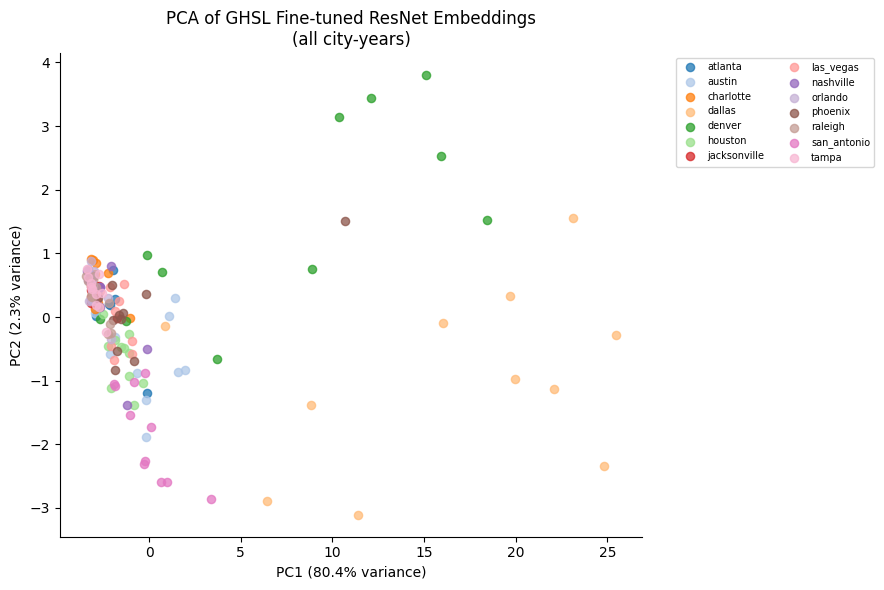

In [21]:
fig, ax = plt.subplots(figsize=(9, 6))

palette = sns.color_palette("tab20", len(METROS))
metro_color = {m: palette[i] for i, m in enumerate(METROS)}

for metro in METROS:
    sub = img_emb_finetuned[img_emb_finetuned["metro"] == metro]

    ax.scatter(
        sub["pc1"],
        sub["pc2"],
        color=metro_color[metro],
        s=35,
        alpha=0.75,
        label=metro
    )

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("PCA of GHSL Fine-tuned ResNet Embeddings\n(all city-years)")

ax.legend(
    fontsize=7,
    ncol=2,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=True
)

sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(
    "figures/04_embedding_pca.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

In [ ]:
emb_cols_frz = [c for c in img_emb_frozen.columns if c.startswith("emb_")]
X_frozen = img_emb_frozen[emb_cols_frz].values

pca_frozen = PCA(n_components=2, random_state=SEED)
coords_frozen = pca_frozen.fit_transform(X_frozen)
img_emb_frozen["pc1"] = coords_frozen[:, 0]

probe_epochs = {2015: 2015, 2020: 2020}
merged_frozen = []
for ghsl_epoch, modis_year in probe_epochs.items():
    sub_emb = img_emb_frozen[img_emb_frozen["year"] == modis_year][["metro","pc1"]]
    sub_gh  = ghsl_summary[ghsl_summary["epoch"] == ghsl_epoch][["metro","built_up_km2"]]
    merged_frozen.append(sub_emb.merge(sub_gh, on="metro"))

probe_frozen = pd.concat(merged_frozen, ignore_index=True)
rho_frozen, pval_frozen = spearmanr(probe_frozen["pc1"], probe_frozen["built_up_km2"])

print("Embedding validation: |PC1| vs GHSL built-up area (Spearman, n=28)")
print("Note: PCA sign is arbitrary so absolute correlation is compared.")
print("-" * 55)
print(f"  Frozen ImageNet ResNet-18   |rho|={abs(rho_frozen):.4f}")
print(f"  GHSL fine-tuned ResNet-18   |rho|={abs(rho):.4f}")
print("-" * 55)
if abs(rho) > abs(rho_frozen):
    print(f"  fine-tuning improved |rho| by {abs(rho) - abs(rho_frozen):+.4f}")
else:
    print(f"  fine-tuning did not improve |rho| (noted as limitation)")
print()
print("Centroid separation (primary validation):")
print(f"  Frozen     : {ratio_frz:.4f}")
print(f"  Fine-tuned : {ratio_ft:.4f}")
print(f"  improvement: {ratio_ft - ratio_frz:+.4f} (+{(ratio_ft/ratio_frz - 1)*100:.1f}%)")

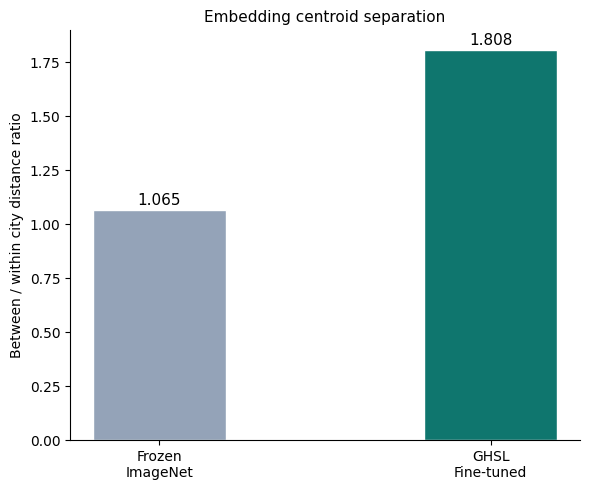

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(
    ["Frozen\nImageNet", "GHSL\nFine-tuned"],
    [ratio_frz, ratio_ft],
    color=["#94a3b8", "#0f766e"],
    width=0.4, edgecolor="white"
)
for bar, val in zip(bars, [ratio_frz, ratio_ft]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=11)

ax.set_ylabel("Between / within city distance ratio")
ax.set_title("Embedding centroid separation",
             fontsize=11)
sns.despine()
plt.tight_layout()
plt.savefig("figures/05_centroid_separation.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()

---
## 5. Stage 2 - Economic Sequence Autoencoder

We learn compressed representations of city economic trajectories using two
architectures and select the better one for Stage 3.

**Input features:** 9 economic-only variables — GDP, employment, unemployment,
permits, derived ratios, and their year-over-year growth rates. All satellite-
derived columns are excluded to keep the two modalities clean.

**MLP autoencoder:** treats each city-year independently. Encodes a single
standardized 9-dim snapshot into a 32-dim bottleneck and reconstructs it.
Produces embeddings for all 140 city-years.

**GRU autoencoder:** encodes a 3-observation rolling window of economic history
ending at year t into a 32-dim bottleneck, then decodes back to the full
sequence. Since 2020 is absent from the panel, sequences are the 3 most recent
available observations — not strictly 3 consecutive calendar years. Produces
embeddings for 112 city-years (first 2 observations per city cannot form a
full window).

**Fair comparison:** both models are evaluated only on the shared 112 city-years
where GRU embeddings exist. The winner proceeds to Stage 3.

**Split:** assigned by target year t.
- Train: 2015–2018
- Val: 2019
- Test: 2021–2023

In [17]:
ECON_FEATURES = [
    "gdp_millions",
    "employment_thousands",
    "unemployment_rate",
    "gdp_per_employee",
    "gdp_millions_growth",
    "employment_thousands_growth",
]

econ_df = econ_df[["metro", "year"] + ECON_FEATURES].copy()
econ_df[ECON_FEATURES] = econ_df[ECON_FEATURES].fillna(0)
econ_df = econ_df.sort_values(["metro", "year"]).reset_index(drop=True)

print(f"panel shape : {econ_df.shape}")
print(f"years       : {sorted(econ_df['year'].unique())}")
print(f"metros      : {len(econ_df['metro'].unique())}")
print(f"null counts :\n{econ_df[ECON_FEATURES].isnull().sum()}")

panel shape : (140, 8)
years       : [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023)]
metros      : 14
null counts :
gdp_millions                   0
employment_thousands           0
unemployment_rate              0
gdp_per_employee               0
gdp_millions_growth            0
employment_thousands_growth    0
dtype: int64


In [18]:
from sklearn.preprocessing import StandardScaler
TRAIN_YEARS_ECON = [2015, 2016, 2017, 2018]
VAL_YEARS_ECON   = [2019]
TEST_YEARS_ECON  = [2021, 2022, 2023]

train_rows = econ_df[econ_df["year"].isin(TRAIN_YEARS_ECON)]
val_rows   = econ_df[econ_df["year"].isin(VAL_YEARS_ECON)]
test_rows  = econ_df[econ_df["year"].isin(TEST_YEARS_ECON)]

scaler = StandardScaler()
scaler.fit(train_rows[ECON_FEATURES])

def scale_split(df):
    out = df.copy()
    out[ECON_FEATURES] = scaler.transform(df[ECON_FEATURES])
    return out

train_scaled = scale_split(train_rows)
val_scaled   = scale_split(val_rows)
test_scaled  = scale_split(test_rows)
full_scaled  = scale_split(econ_df)

print(f"train rows : {len(train_scaled)}")
print(f"val rows   : {len(val_scaled)}")
print(f"test rows  : {len(test_scaled)}")
print(f"full rows  : {len(full_scaled)}")

train rows : 56
val rows   : 14
test rows  : 42
full rows  : 140


In [19]:
class MLPAutoencoderDataset(Dataset):
    def __init__(self, df):
        arr = df[ECON_FEATURES].values.astype(np.float32)
        self.X      = torch.as_tensor(arr, dtype=torch.float32)
        self.metros = df["metro"].tolist()
        self.years  = df["year"].tolist()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.metros[idx], self.years[idx]


class GRUAutoencoderDataset(Dataset):
    def __init__(self, full_scaled_df, target_years, window=3):
        self.samples = []
        full_scaled_df = full_scaled_df.sort_values(["metro", "year"])

        for metro in full_scaled_df["metro"].unique():
            city_df         = full_scaled_df[full_scaled_df["metro"] == metro].sort_values("year")
            years_available = city_df["year"].tolist()
            features        = city_df[ECON_FEATURES].values.astype(np.float32)

            for i, yr in enumerate(years_available):
                if yr not in target_years:
                    continue
                if i < window - 1:
                    continue
                seq = features[i - window + 1: i + 1]
                self.samples.append((
                    torch.as_tensor(seq.copy(),          dtype=torch.float32),
                    torch.as_tensor(features[i].copy(),  dtype=torch.float32),
                    metro,
                    yr,
                ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

In [20]:
WINDOW = 3

train_mlp_ds = MLPAutoencoderDataset(train_scaled)
val_mlp_ds   = MLPAutoencoderDataset(val_scaled)
test_mlp_ds  = MLPAutoencoderDataset(test_scaled)

train_gru_ds = GRUAutoencoderDataset(full_scaled, TRAIN_YEARS_ECON, WINDOW)
val_gru_ds   = GRUAutoencoderDataset(full_scaled, VAL_YEARS_ECON,   WINDOW)
test_gru_ds  = GRUAutoencoderDataset(full_scaled, TEST_YEARS_ECON,  WINDOW)

train_mlp_loader = DataLoader(train_mlp_ds, batch_size=16, shuffle=True)
val_mlp_loader   = DataLoader(val_mlp_ds,   batch_size=16, shuffle=False)
test_mlp_loader  = DataLoader(test_mlp_ds,  batch_size=16, shuffle=False)

train_gru_loader = DataLoader(train_gru_ds, batch_size=16, shuffle=True)
val_gru_loader   = DataLoader(val_gru_ds,   batch_size=16, shuffle=False)
test_gru_loader  = DataLoader(test_gru_ds,  batch_size=16, shuffle=False)

In [21]:
class MLPAutoencoder(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64, latent_dim=32, dropout=0.1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x):
        z     = self.encoder(x)
        recon = self.decoder(z)
        return recon, z

    @torch.no_grad()
    def encode(self, x):
        self.eval()
        return self.encoder(x)

class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64, latent_dim=32,
                 dropout=0.1, window=3):
        super().__init__()
        self.window = window

        self.enc_lstm   = nn.LSTM(input_dim, hidden_dim, num_layers=1,
                                  batch_first=True)
        self.enc_drop   = nn.Dropout(dropout)
        self.enc_linear = nn.Linear(hidden_dim, latent_dim)

        self.dec_lstm   = nn.LSTM(latent_dim, hidden_dim, num_layers=1,
                                  batch_first=True)
        self.dec_linear = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        _, (h, _) = self.enc_lstm(x)
        h         = h.squeeze(0)
        h         = self.enc_drop(h)
        z         = self.enc_linear(h)
        z_rep     = z.unsqueeze(1).repeat(1, self.window, 1)
        out, _    = self.dec_lstm(z_rep)
        recon     = self.dec_linear(out)
        return recon, z

    @torch.no_grad()
    def encode(self, x):
        self.eval()
        _, (h, _) = self.enc_lstm(x)
        h         = h.squeeze(0)
        h         = self.enc_drop(h)
        return self.enc_linear(h)


lstm_ae = LSTMAutoencoder(input_dim=len(ECON_FEATURES),
                          hidden_dim=64, latent_dim=32, dropout=0.1,
                          window=WINDOW).to(device)

total_lstm = sum(p.numel() for p in lstm_ae.parameters())
print(f"LSTM autoencoder params : {total_lstm:,}")

class GRUAutoencoder(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64, latent_dim=32,
                 dropout=0.1, window=3):
        super().__init__()
        self.window  = window

        self.enc_gru    = nn.GRU(input_dim, hidden_dim, num_layers=1,
                                 batch_first=True)
        self.enc_drop   = nn.Dropout(dropout)
        self.enc_linear = nn.Linear(hidden_dim, latent_dim)

        self.dec_gru    = nn.GRU(latent_dim, hidden_dim, num_layers=1,
                                 batch_first=True)
        self.dec_linear = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        _, h   = self.enc_gru(x)
        h      = h.squeeze(0)
        h      = self.enc_drop(h)
        z      = self.enc_linear(h)
        z_rep  = z.unsqueeze(1).repeat(1, self.window, 1)
        out, _ = self.dec_gru(z_rep)
        recon  = self.dec_linear(out)
        return recon, z

    @torch.no_grad()
    def encode(self, x):
        self.eval()
        _, h = self.enc_gru(x)
        h    = h.squeeze(0)
        h    = self.enc_drop(h)
        return self.enc_linear(h)


mlp_ae = MLPAutoencoder(input_dim=len(ECON_FEATURES),
                        hidden_dim=64, latent_dim=32, dropout=0.1).to(device)
gru_ae = GRUAutoencoder(input_dim=len(ECON_FEATURES),
                        hidden_dim=64, latent_dim=32, dropout=0.1,
                        window=WINDOW).to(device)

total_mlp = sum(p.numel() for p in mlp_ae.parameters())
total_gru = sum(p.numel() for p in gru_ae.parameters())
print(f"MLP autoencoder params : {total_mlp:,}")
print(f"GRU autoencoder params : {total_gru:,}")

LSTM autoencoder params : 45,990
MLP autoencoder params : 5,030
GRU autoencoder params : 35,110


In [22]:
def train_autoencoder(model, model_type, train_loader, val_loader,
                      epochs=200, lr=1e-3, patience=15, ckpt_name="ae.pt"):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6
    )

    best_val_loss = float("inf")
    epochs_no_imp = 0
    history       = {"train_loss": [], "val_loss": []}

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0

        for batch in train_loader:
            if model_type == "mlp":
                x, _, _ = batch
                x = x.to(device)
                recon, _ = model(x)
                loss = F.mse_loss(recon, x)
            else:
                seq, _, _, _ = batch
                seq = seq.to(device)
                recon, _ = model(seq)
                loss = F.mse_loss(recon, seq)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        avg_train = train_loss / len(train_loader)
        history["train_loss"].append(avg_train)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                if model_type == "mlp":
                    x, _, _ = batch
                    x = x.to(device)
                    recon, _ = model(x)
                    loss = F.mse_loss(recon, x)
                else:
                    seq, _, _, _ = batch
                    seq = seq.to(device)
                    recon, _ = model(seq)
                    loss = F.mse_loss(recon, seq)
                val_loss += loss.item()

        avg_val = val_loss / len(val_loader)
        history["val_loss"].append(avg_val)
        scheduler.step(avg_val)

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            epochs_no_imp = 0
            torch.save(model.state_dict(), CKPT_DIR / ckpt_name)
        else:
            epochs_no_imp += 1

        if epoch % 20 == 0:
            print(f"epoch {epoch:3d}/{epochs}  "
                  f"train={avg_train:.4f}  val={avg_val:.4f}  "
                  f"best={best_val_loss:.4f}")

        if epochs_no_imp >= patience:
            print(f"\nearly stopping at epoch {epoch}")
            break

    model.load_state_dict(
        torch.load(CKPT_DIR / ckpt_name, map_location=device)
    )
    model.eval()
    print(f"best val MSE: {best_val_loss:.4f}")
    return history


if RETRAIN_LSTM:
    set_seed(SEED)
    print("Training MLP autoencoder...")
    hist_mlp = train_autoencoder(
        mlp_ae, "mlp", train_mlp_loader, val_mlp_loader,
        epochs=200, lr=1e-3, patience=15, ckpt_name="mlp_ae.pt"
    )

    set_seed(SEED)
    print("\nTraining GRU autoencoder...")
    hist_gru = train_autoencoder(
        gru_ae, "gru", train_gru_loader, val_gru_loader,
        epochs=200, lr=1e-3, patience=15, ckpt_name="gru_ae.pt"
    )

    set_seed(SEED)
    print("\nTraining LSTM autoencoder...")
    hist_lstm = train_autoencoder(
        lstm_ae, "lstm", train_gru_loader, val_gru_loader,
        epochs=200, lr=1e-3, patience=15, ckpt_name="lstm_ae.pt"
    )
else:
    for ckpt, model in [("mlp_ae.pt", mlp_ae),
                        ("gru_ae.pt", gru_ae),
                        ("lstm_ae.pt", lstm_ae)]:
        ckpt_path = CKPT_DIR / ckpt
        assert ckpt_path.exists(), \
            f"Checkpoint not found: {ckpt_path}. Set RETRAIN_LSTM=True."
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        model.eval()
    print("loaded MLP, GRU, LSTM autoencoders from checkpoints")

loaded MLP, GRU, LSTM autoencoders from checkpoints


In [26]:
def eval_reconstruction_mse(model, model_type, loader):
    model.eval()
    total_loss = 0.0
    total_n = 0

    with torch.no_grad():
        for batch in loader:
            if model_type == "mlp":
                x, _, _ = batch
            elif model_type in ["gru", "lstm"]:
                x, _, _, _ = batch
            else:
                raise ValueError(f"Unknown model_type: {model_type}")

            x = x.to(device)

            recon, _ = model(x)

            loss = F.mse_loss(recon, x, reduction="sum")
            total_loss += loss.item()
            total_n += x.numel()

    return total_loss / total_n

In [27]:
mlp_test_mse  = eval_reconstruction_mse(mlp_ae,  "mlp",  test_mlp_loader)
gru_test_mse  = eval_reconstruction_mse(gru_ae,  "gru",  test_gru_loader)
lstm_test_mse = eval_reconstruction_mse(lstm_ae, "lstm", test_gru_loader)

print("Test reconstruction MSE (2021-2023 holdout)")
print("-" * 45)
print(f"  MLP autoencoder  : {mlp_test_mse:.4f}")
print(f"  GRU autoencoder  : {gru_test_mse:.4f}")
print(f"  LSTM autoencoder : {lstm_test_mse:.4f}")
print("-" * 45)
scores = {"MLP": mlp_test_mse, "GRU": gru_test_mse, "LSTM": lstm_test_mse}
winner = min(scores, key=scores.get)
print(f"  winner           : {winner}")

Test reconstruction MSE (2021-2023 holdout)
---------------------------------------------
  MLP autoencoder  : 0.0974
  GRU autoencoder  : 1.7160
  LSTM autoencoder : 1.8812
---------------------------------------------
  winner           : MLP


We compared static MLP, GRU, and LSTM autoencoders for the economic embedding branch. The MLP achieved the lowest reconstruction error on the 2021–2023 holdout, so we use the 32-dimensional MLP bottleneck embeddings as the economic representation for Stage 3.

In [ ]:
def extract_econ_embeddings(model, model_type, full_scaled_df, window=3):
    model.eval()
    records = []

    if model_type == "mlp":
        for _, row in full_scaled_df.iterrows():
            x = torch.from_numpy(
                row[ECON_FEATURES].values.astype(np.float32)
            ).unsqueeze(0).to(device)
            z = model.encode(x).squeeze(0).cpu().numpy()
            rec = {"metro": row["metro"], "year": int(row["year"])}
            for d in range(len(z)):
                rec[f"emb_{d}"] = z[d]
            records.append(rec)
    else:
        city_dfs = {m: g.sort_values("year").reset_index(drop=True)
                    for m, g in full_scaled_df.groupby("metro")}
        for metro, city_df in city_dfs.items():
            feats = city_df[ECON_FEATURES].values.astype(np.float32)
            years = city_df["year"].tolist()
            for i in range(window - 1, len(years)):
                seq   = feats[i - window + 1: i + 1]
                seq_t = torch.tensor(seq) .unsqueeze(0).to(device)
                z     = model.encode(seq_t).squeeze(0).cpu().numpy()
                rec   = {"metro": metro, "year": int(years[i])}
                for d in range(len(z)):
                    rec[f"emb_{d}"] = z[d]
                records.append(rec)

    return pd.DataFrame(records)


econ_emb_mlp = extract_econ_embeddings(mlp_ae, "mlp", full_scaled)
econ_emb_mlp.to_csv("data/econ_embeddings_mlp.csv", index=False)

print(f"economic embeddings shape : {econ_emb_mlp.shape}")
print(f"saved to                  : data/econ_embeddings_mlp.csv")

---
## 6. Stage 3 — Multimodal VAE with Contrastive Alignment

We learn a shared 16-dimensional latent representation for each city-year
by jointly encoding satellite image embeddings (512-dim, Stage 1) and
economic embeddings (32-dim, Stage 2).

**Architecture:**
- Image projection  : MLP 512 → 128 → 64 → 32
- Economic projection: MLP 32 → 64 → 32
- Fusion            : concat [img_32, econ_32] → 64-dim
- Joint encoder     : MLP 64 → 32 → (μ, logσ²) in 16-dim latent space
- Image decoder     : MLP 16 → 64 → 128 → 512
- Economic decoder  : MLP 16 → 32 → 64 → 32

**Loss:**
- Image reconstruction MSE
- Economic reconstruction MSE
- KL divergence with β warmup (0.1 → 1.0 over 50 epochs)
- InfoNCE contrastive loss (τ=0.5) on projected embeddings — outside class

**Split:** Train 2013–2018, Val 2019, Test 2021–2023

**Anomaly score:** reconstruction error (both modalities) + KL per city-year

In [23]:
img_emb_ft = pd.read_csv("data/img_embeddings_finetuned.csv")
econ_emb   = pd.read_csv("data/econ_embeddings_mlp.csv")

img_emb_cols_raw  = [c for c in img_emb_ft.columns if c.startswith("emb_")]
econ_emb_cols_raw = [c for c in econ_emb.columns   if c.startswith("emb_")]

img_emb_ft = img_emb_ft.rename(columns={c: f"{c}_img"  for c in img_emb_cols_raw})
econ_emb   = econ_emb.rename(  columns={c: f"{c}_econ" for c in econ_emb_cols_raw})

merged = img_emb_ft.merge(econ_emb, on=["metro", "year"])

IMG_EMB_COLS  = [c for c in merged.columns if c.endswith("_img")]
ECON_EMB_COLS = [c for c in merged.columns if c.endswith("_econ")]

print(f"image embeddings     : {img_emb_ft.shape}")
print(f"economic embeddings  : {econ_emb.shape}")
print(f"merged intersection  : {merged.shape}")
print(f"img dims             : {len(IMG_EMB_COLS)}")
print(f"econ dims            : {len(ECON_EMB_COLS)}")
print(f"years in merged      : {sorted(merged['year'].unique())}")
print(f"metros in merged     : {len(merged['metro'].unique())}")

image embeddings     : (154, 514)
economic embeddings  : (140, 34)
merged intersection  : (140, 546)
img dims             : 512
econ dims            : 32
years in merged      : [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023)]
metros in merged     : 14


In [24]:
IMG_EMB_COLS  = [c for c in merged.columns
                 if c.endswith("_img") and c.startswith("emb_")]
ECON_EMB_COLS = [c for c in merged.columns
                 if c.endswith("_econ") and c.startswith("emb_")]

print(f"image embedding dims : {len(IMG_EMB_COLS)}")
print(f"econ embedding dims  : {len(ECON_EMB_COLS)}")

TRAIN_YEARS_VAE = [2013, 2014, 2015, 2016, 2017, 2018]
VAL_YEARS_VAE   = [2019]
TEST_YEARS_VAE  = [2021, 2022, 2023]

train_vae = merged[merged["year"].isin(TRAIN_YEARS_VAE)].reset_index(drop=True)
val_vae   = merged[merged["year"].isin(VAL_YEARS_VAE)].reset_index(drop=True)
test_vae  = merged[merged["year"].isin(TEST_YEARS_VAE)].reset_index(drop=True)

print(f"\ntrain : {len(train_vae)} city-years")
print(f"val   : {len(val_vae)} city-years")
print(f"test  : {len(test_vae)} city-years")

image embedding dims : 512
econ embedding dims  : 32

train : 84 city-years
val   : 14 city-years
test  : 42 city-years


In [25]:
from sklearn.preprocessing import StandardScaler
img_scaler  = StandardScaler()
econ_scaler = StandardScaler()

img_scaler.fit(train_vae[IMG_EMB_COLS])
econ_scaler.fit(train_vae[ECON_EMB_COLS])

def scale_vae_split(df):
    out = df.copy()
    out[IMG_EMB_COLS]  = img_scaler.transform(df[IMG_EMB_COLS])
    out[ECON_EMB_COLS] = econ_scaler.transform(df[ECON_EMB_COLS])
    return out

train_vae_s = scale_vae_split(train_vae)
val_vae_s   = scale_vae_split(val_vae)
test_vae_s  = scale_vae_split(test_vae)
full_vae_s  = scale_vae_split(merged)

print(f"image mean (train, ~0) : {train_vae_s[IMG_EMB_COLS].values.mean():.4f}")
print(f"econ  mean (train, ~0) : {train_vae_s[ECON_EMB_COLS].values.mean():.4f}")

image mean (train, ~0) : -0.0000
econ  mean (train, ~0) : -0.0000


In [26]:
class MultimodalVAEDataset(Dataset):
    def __init__(self, df, img_cols, econ_cols):
        self.img    = torch.tensor(df[img_cols].values.astype(np.float32), dtype=torch.float32)
        self.econ   = torch.tensor(df[econ_cols].values.astype(np.float32), dtype=torch.float32)
        self.metros = df["metro"].tolist()
        self.years  = df["year"].tolist()

    def __len__(self):
        return len(self.img)

    def __getitem__(self, idx):
        return self.img[idx], self.econ[idx], self.metros[idx], self.years[idx]


train_vae_ds = MultimodalVAEDataset(train_vae_s, IMG_EMB_COLS, ECON_EMB_COLS)
val_vae_ds   = MultimodalVAEDataset(val_vae_s,   IMG_EMB_COLS, ECON_EMB_COLS)
test_vae_ds  = MultimodalVAEDataset(test_vae_s,  IMG_EMB_COLS, ECON_EMB_COLS)
full_vae_ds  = MultimodalVAEDataset(full_vae_s,  IMG_EMB_COLS, ECON_EMB_COLS)

train_vae_loader = DataLoader(train_vae_ds, batch_size=16,
                              shuffle=True,  num_workers=0)
val_vae_loader   = DataLoader(val_vae_ds,   batch_size=16,
                              shuffle=False, num_workers=0)
test_vae_loader  = DataLoader(test_vae_ds,  batch_size=16,
                              shuffle=False, num_workers=0)
full_vae_loader  = DataLoader(full_vae_ds,  batch_size=16,
                              shuffle=False, num_workers=0)

print(f"train:{len(train_vae_ds)}  val:{len(val_vae_ds)}  "
      f"test:{len(test_vae_ds)}  full:{len(full_vae_ds)}")

train:84  val:14  test:42  full:140


In [27]:
class MultimodalVAE(nn.Module):
    """
    Multimodal VAE with projection and joint fusion.

    Each modality is projected to 32-dim, concatenated to 64-dim,
    then passed through a joint encoder to produce (mu, logvar) in
    16-dim shared latent space. Two decoders reconstruct each modality.
    Contrastive loss is applied to the 32-dim projected embeddings.

    Modality dropout: during training each modality is independently
    zeroed with probability `modality_dropout`. This forces the model
    to learn useful representations from either modality alone, enabling
    single-modality inference at test time for nowcasting applications.
    """

    def __init__(self, img_dim=512, econ_dim=32, proj_dim=32,
                 latent_dim=16, dropout=0.1, modality_dropout=0.3):
        super().__init__()
        self.latent_dim       = latent_dim
        self.modality_dropout = modality_dropout

        self.img_proj = nn.Sequential(
            nn.Linear(img_dim, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64),      nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, proj_dim), nn.ReLU(),
        )

        self.econ_proj = nn.Sequential(
            nn.Linear(econ_dim, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, proj_dim), nn.ReLU(),
        )

        self.joint_encoder = nn.Sequential(
            nn.Linear(proj_dim * 2, 32), nn.ReLU(), nn.Dropout(dropout),
        )
        self.mu_head     = nn.Linear(32, latent_dim)
        self.logvar_head = nn.Linear(32, latent_dim)

        self.img_decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),  nn.ReLU(),
            nn.Linear(64, 128),         nn.ReLU(),
            nn.Linear(128, img_dim),
        )

        self.econ_decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),  nn.ReLU(),
            nn.Linear(32, 64),          nn.ReLU(),
            nn.Linear(64, econ_dim),
        )

    def project(self, img, econ):
        img_p  = self.img_proj(img)
        econ_p = self.econ_proj(econ)

        if self.training and self.modality_dropout > 0:
            r = torch.rand(1).item()
            if r < self.modality_dropout / 2:
                img_p  = torch.zeros_like(img_p)
            elif r < self.modality_dropout:
                econ_p = torch.zeros_like(econ_p)

        return img_p, econ_p

    def encode(self, img_p, econ_p):
        joint  = torch.cat([img_p, econ_p], dim=1)
        h      = self.joint_encoder(joint)
        return self.mu_head(h), self.logvar_head(h)

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            return mu + std * torch.randn_like(std)
        return mu

    def forward(self, img, econ):
        img_p, econ_p = self.project(img, econ)
        mu, logvar    = self.encode(img_p, econ_p)
        z             = self.reparameterize(mu, logvar)
        recon_img     = self.img_decoder(z)
        recon_econ    = self.econ_decoder(z)
        return recon_img, recon_econ, z, mu, logvar, img_p, econ_p

    @torch.no_grad()
    def encode_joint(self, img, econ):
        self.eval()
        img_p, econ_p = self.project(img, econ)
        mu, _         = self.encode(img_p, econ_p)
        return mu

    @torch.no_grad()
    def encode_img_only(self, img):
        self.eval()
        img_p  = self.img_proj(img)
        econ_p = torch.zeros(img.size(0), img_p.size(-1)).to(img.device)
        mu, _  = self.encode(img_p, econ_p)
        return mu

    @torch.no_grad()
    def encode_econ_only(self, econ):
        self.eval()
        econ_p = self.econ_proj(econ)
        img_p  = torch.zeros(econ.size(0), econ_p.size(-1)).to(econ.device)
        mu, _  = self.encode(img_p, econ_p)
        return mu
    
    @torch.no_grad()
    def predict_econ_from_img(self, img):
        """
        Nowcasting: given only satellite image embedding, predict
        economic state. Used when economic data is unavailable or delayed.
        """
        self.eval()
        z          = self.encode_img_only(img)
        recon_econ = self.econ_decoder(z)
        return recon_econ

vae = MultimodalVAE(
    img_dim=len(IMG_EMB_COLS),
    econ_dim=len(ECON_EMB_COLS),
    proj_dim=32,
    latent_dim=16,
    dropout=0.1,
    modality_dropout=0.3,
).to(device)

total_vae = sum(p.numel() for p in vae.parameters())
print(f"multimodal VAE params : {total_vae:,}")
print(f"modality dropout      : {vae.modality_dropout}")

multimodal VAE params : 163,520
modality dropout      : 0.3


In [28]:
def info_nce_loss(z_img, z_econ, temperature=0.5):
    """
    InfoNCE contrastive loss (CLIP-style cross-modal alignment).
    Positive pair: (z_img[i], z_econ[i]) — same city-year.
    Negatives: all other city-years in the batch.
    Applied to deterministic projected embeddings, not sampled z.
    """
    B = z_img.size(0)
    if B < 2:
        return torch.tensor(0.0, device=z_img.device)

    z_img_n  = F.normalize(z_img,  dim=1)
    z_econ_n = F.normalize(z_econ, dim=1)

    logits = torch.matmul(z_img_n, z_econ_n.T) / temperature
    labels = torch.arange(B, device=z_img.device)

    loss_img  = F.cross_entropy(logits,   labels)
    loss_econ = F.cross_entropy(logits.T, labels)
    return (loss_img + loss_econ) / 2.0


def vae_loss(recon_img, img, recon_econ, econ,
             mu, logvar, img_p, econ_p,
             beta=1.0, lambda_contrast=0.5, temperature=0.5):

    recon_img_loss  = F.mse_loss(recon_img,  img)
    recon_econ_loss = F.mse_loss(recon_econ, econ)
    kl_loss = -0.5 * torch.mean(
        1 + logvar - mu.pow(2) - logvar.exp()
    )
    contrastive = info_nce_loss(img_p, econ_p, temperature)

    total = (recon_img_loss + recon_econ_loss
             + beta * kl_loss
             + lambda_contrast * contrastive)

    return total, recon_img_loss, recon_econ_loss, kl_loss, contrastive

In [29]:
def train_multimodal_vae(model, train_loader, val_loader,
                         epochs=200, lr=1e-3, patience=20,
                         beta_start=0.1, beta_end=1.0, beta_warmup=50,
                         lambda_contrast=0.5, temperature=0.5):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=8, min_lr=1e-6
    )

    best_val_loss = float("inf")
    epochs_no_imp = 0

    history = {k: [] for k in [
        "train_loss", "val_loss", "val_img_only_econ",
        "recon_img", "recon_econ", "kl", "contrastive"
    ]}

    for epoch in range(1, epochs + 1):
        beta = min(
            beta_end,
            beta_start + (beta_end - beta_start) * epoch / beta_warmup
        )

        model.train()
        totals = {k: 0.0 for k in ["loss", "recon_img", "recon_econ", "kl", "contrast"]}

        for img, econ, _, _ in train_loader:
            img = img.to(device)
            econ = econ.to(device)

            recon_img, recon_econ, z, mu, logvar, img_p, econ_p = model(img, econ)

            loss, rl_img, rl_econ, kl, contrast = vae_loss(
                recon_img, img,
                recon_econ, econ,
                mu, logvar,
                img_p, econ_p,
                beta=beta,
                lambda_contrast=lambda_contrast,
                temperature=temperature,
            )

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            totals["loss"] += loss.item()
            totals["recon_img"] += rl_img.item()
            totals["recon_econ"] += rl_econ.item()
            totals["kl"] += kl.item()
            totals["contrast"] += contrast.item()

        for k in totals:
            totals[k] /= len(train_loader)

        model.eval()
        val_loss_total = 0.0
        val_img_only_econ_total = 0.0

        with torch.no_grad():
            for img, econ, _, _ in val_loader:
                img = img.to(device)
                econ = econ.to(device)

                recon_img, recon_econ, z, mu, logvar, img_p, econ_p = model(img, econ)

                loss, _, _, _, _ = vae_loss(
                    recon_img, img,
                    recon_econ, econ,
                    mu, logvar,
                    img_p, econ_p,
                    beta=beta,
                    lambda_contrast=lambda_contrast,
                    temperature=temperature,
                )

                econ_from_img = model.predict_econ_from_img(img)
                img_only_econ_loss = F.mse_loss(econ_from_img, econ)

                val_loss_total += loss.item()
                val_img_only_econ_total += img_only_econ_loss.item()

        avg_val = val_loss_total / len(val_loader)
        avg_val_img_only_econ = val_img_only_econ_total / len(val_loader)

        scheduler.step(avg_val)

        history["train_loss"].append(totals["loss"])
        history["val_loss"].append(avg_val)
        history["val_img_only_econ"].append(avg_val_img_only_econ)
        history["recon_img"].append(totals["recon_img"])
        history["recon_econ"].append(totals["recon_econ"])
        history["kl"].append(totals["kl"])
        history["contrastive"].append(totals["contrast"])

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            epochs_no_imp = 0
            torch.save(model.state_dict(), CKPT_DIR / "multimodal_vae.pt")
        else:
            epochs_no_imp += 1

        if epoch % 20 == 0:
            print(
                f"epoch {epoch:3d}/{epochs}  β={beta:.2f}  "
                f"loss={totals['loss']:.4f}  "
                f"val={avg_val:.4f}  "
                f"img_only_econ={avg_val_img_only_econ:.4f}  "
                f"recon_img={totals['recon_img']:.4f}  "
                f"recon_econ={totals['recon_econ']:.4f}  "
                f"kl={totals['kl']:.4f}  "
                f"contrast={totals['contrast']:.4f}"
            )

        if epochs_no_imp >= patience:
            print(f"\nearly stopping at epoch {epoch}")
            break

    model.load_state_dict(
        torch.load(CKPT_DIR / "multimodal_vae.pt", map_location=device)
    )
    model.eval()

    print(f"\nbest val loss: {best_val_loss:.4f}")
    return history


set_seed(SEED)

vae = MultimodalVAE(
    img_dim=len(IMG_EMB_COLS),
    econ_dim=len(ECON_EMB_COLS),
    proj_dim=32,
    latent_dim=16,
    dropout=0.1,
    modality_dropout=0.3,
).to(device)

if RETRAIN_VAE:
    set_seed(SEED)
    vae_history = train_multimodal_vae(
        vae, train_vae_loader, val_vae_loader,
        epochs=200, lr=1e-3, patience=30,
        beta_start=0.1, beta_end=1.0, beta_warmup=50,
        lambda_contrast=0.1,
        temperature=0.5,
    )
else:
    ckpt_path = CKPT_DIR / "multimodal_vae.pt"
    assert ckpt_path.exists(), (
        f"Checkpoint not found: {ckpt_path}. Set RETRAIN_VAE=True."
    )
    vae.load_state_dict(torch.load(ckpt_path, map_location=device))
    vae.eval()
    print("loaded multimodal VAE from checkpoint")

loaded multimodal VAE from checkpoint


In [30]:
val_img_t  = torch.tensor(
    val_vae_s[IMG_EMB_COLS].values.astype(np.float32),
    dtype=torch.float32).to(device)
val_econ_t = torch.tensor(
    val_vae_s[ECON_EMB_COLS].values.astype(np.float32),
    dtype=torch.float32).to(device)

with torch.no_grad():
    nowcast_val  = vae.predict_econ_from_img(val_img_t)
    joint_val    = vae(val_img_t, val_econ_t)[1]

nowcast_val_mse = F.mse_loss(nowcast_val,  val_econ_t).item()
joint_val_mse   = F.mse_loss(joint_val,    val_econ_t).item()

city_econ_mean   = train_vae_s.groupby("metro")[ECON_EMB_COLS].mean()
val_metros       = val_vae_s["metro"].tolist()
baseline_val     = torch.tensor(
    np.stack([city_econ_mean.loc[m].values for m in val_metros]).astype(np.float32),
    dtype=torch.float32).to(device)
baseline_val_mse = F.mse_loss(baseline_val, val_econ_t).item()

print("Nowcasting evaluation (2019 validation)")
print("=" * 55)
print(f"  Per-city mean baseline   : {baseline_val_mse:.4f}")
print(f"  Joint z (both modalities): {joint_val_mse:.4f}")
print(f"  Image-only nowcast       : {nowcast_val_mse:.4f}")
print("=" * 55)

Nowcasting evaluation (2019 validation)
  Per-city mean baseline   : 0.5262
  Joint z (both modalities): 0.6547
  Image-only nowcast       : 0.8995


In [31]:
if RETRAIN_VAE:
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))

    axes[0,0].plot(vae_history["train_loss"], label="train", color="#2563eb")
    axes[0,0].plot(vae_history["val_loss"],   label="val",   color="#2563eb",
                   linestyle="--")
    axes[0,0].set_title("Total loss")
    axes[0,0].legend()
    sns.despine(ax=axes[0,0])

    axes[0,1].plot(vae_history["recon_img"],  label="image",    color="#0f766e")
    axes[0,1].plot(vae_history["recon_econ"], label="economic", color="#7c3aed")
    axes[0,1].set_title("Reconstruction loss per modality")
    axes[0,1].legend()
    sns.despine(ax=axes[0,1])

    axes[1,0].plot(vae_history["kl"], color="#e63946")
    axes[1,0].set_title("KL divergence")
    sns.despine(ax=axes[1,0])

    axes[1,1].plot(vae_history["contrastive"], color="#f59e0b")
    axes[1,1].set_title("InfoNCE contrastive loss")
    sns.despine(ax=axes[1,1])

    for ax in axes.flat:
        ax.set_xlabel("Epoch")

    plt.suptitle("Stage 3 Multimodal VAE Training Curves",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("figures/08_vae_training.png", dpi=150,
                bbox_inches="tight", facecolor="white")
    plt.show()

In [32]:
def extract_latents(model, loader):
    model.eval()
    records = []

    with torch.no_grad():
        for img, econ, metros, years in loader:
            img  = img.to(device)
            econ = econ.to(device)

            recon_img, recon_econ, z, mu, logvar, img_p, econ_p = model(img, econ)

            kl_per_sample  = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1)
            recon_img_err  = F.mse_loss(recon_img,  img,  reduction="none").mean(dim=1)
            recon_econ_err = F.mse_loss(recon_econ, econ, reduction="none").mean(dim=1)
            anomaly_score  = recon_img_err + recon_econ_err + kl_per_sample

            for i in range(len(metros)):
                rec = {
                    "metro":          metros[i],
                    "year":           int(years[i]),
                    "kl":             kl_per_sample[i].item(),
                    "recon_img_err":  recon_img_err[i].item(),
                    "recon_econ_err": recon_econ_err[i].item(),
                    "anomaly_score":  anomaly_score[i].item(),
                }
                z_np = mu[i].cpu().numpy()
                for d in range(len(z_np)):
                    rec[f"z_{d}"] = z_np[d]
                records.append(rec)

    return pd.DataFrame(records)


latents_path = Path("data/latents_full.csv")

if latents_path.exists():
    latents_full = pd.read_csv(latents_path)
    print(f"loaded latents : {latents_full.shape}")
else:
    latents_full = extract_latents(vae, full_vae_loader)
    latents_full.to_csv(latents_path, index=False)
    print(f"latent vectors shape : {latents_full.shape}")

print(f"anomaly score stats:")
print(f"  mean : {latents_full['anomaly_score'].mean():.4f}")
print(f"  max  : {latents_full['anomaly_score'].max():.4f}")
print(f"  min  : {latents_full['anomaly_score'].min():.4f}")

loaded latents : (140, 22)
anomaly score stats:
  mean : 3.8211
  max  : 19.2420
  min  : 0.8523


In [33]:
vae.eval()

test_img_t  = torch.tensor(
    test_vae_s[IMG_EMB_COLS].values.astype(np.float32),
    dtype=torch.float32).to(device)
test_econ_t = torch.tensor(
    test_vae_s[ECON_EMB_COLS].values.astype(np.float32),
    dtype=torch.float32).to(device)

with torch.no_grad():
    recon_img, recon_econ, z, mu, logvar, img_p, econ_p = vae(
        test_img_t, test_econ_t)

recon_img_mse  = F.mse_loss(recon_img,  test_img_t).item()
recon_econ_mse = F.mse_loss(recon_econ, test_econ_t).item()

city_img_mean  = train_vae_s.groupby("metro")[IMG_EMB_COLS].mean()
city_econ_mean = train_vae_s.groupby("metro")[ECON_EMB_COLS].mean()
test_metros    = test_vae_s["metro"].tolist()

img_baseline_t  = torch.tensor(np.stack([
    city_img_mean.loc[m].values for m in test_metros
]).astype(np.float32), dtype=torch.float32).to(device)
econ_baseline_t = torch.tensor(np.stack([
    city_econ_mean.loc[m].values for m in test_metros
]).astype(np.float32), dtype=torch.float32).to(device)

img_baseline_mse  = F.mse_loss(img_baseline_t,  test_img_t).item()
econ_baseline_mse = F.mse_loss(econ_baseline_t, test_econ_t).item()

print("Test reconstruction MSE vs per-city mean baseline (2021-2023)")
print("-" * 60)
print(f"  Image  VAE={recon_img_mse:.4f}   per-city={img_baseline_mse:.4f}   "
      f"improvement={((img_baseline_mse-recon_img_mse)/img_baseline_mse*100):+.1f}%")
print(f"  Econ   VAE={recon_econ_mse:.4f}   per-city={econ_baseline_mse:.4f}   "
      f"improvement={((econ_baseline_mse-recon_econ_mse)/econ_baseline_mse*100):+.1f}%")

Test reconstruction MSE vs per-city mean baseline (2021-2023)
------------------------------------------------------------
  Image  VAE=0.2462   per-city=0.5014   improvement=+50.9%
  Econ   VAE=1.9881   per-city=2.0288   improvement=+2.0%


In [35]:
import umap

Z_COLS = [c for c in latents_full.columns if c.startswith("z_")]
X_z    = latents_full[Z_COLS].values

reducer   = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=10, min_dist=0.1)
coords_z  = reducer.fit_transform(X_z)

latents_full["umap1"] = coords_z[:, 0]
latents_full["umap2"] = coords_z[:, 1]

print("UMAP complete")
print(f"latents shape : {latents_full.shape}")

UMAP complete
latents shape : (140, 24)


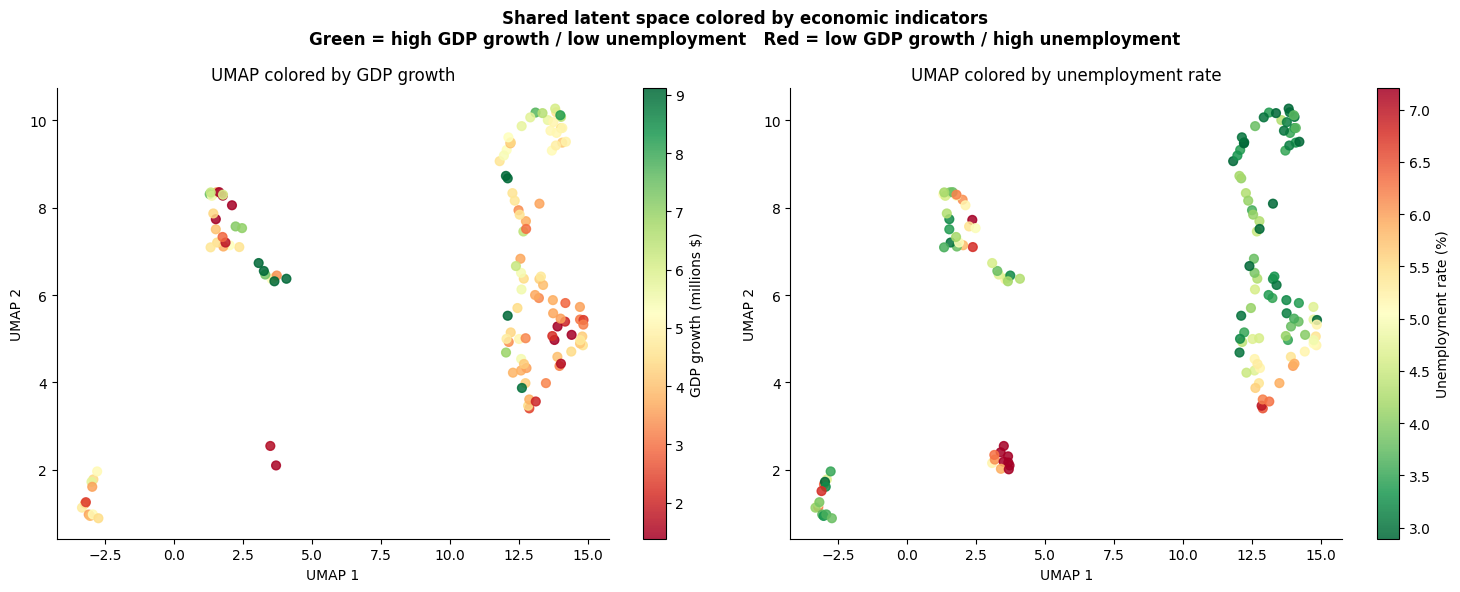

In [41]:
econ_raw = pd.read_csv(ECON_PATH)

latents_econ = latents_full.merge(
    econ_raw[["metro", "year", "gdp_millions_growth", "unemployment_rate"]],
    on=["metro", "year"], how="left"
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sc1 = axes[0].scatter(
    latents_econ["umap1"], latents_econ["umap2"],
    c=latents_econ["gdp_millions_growth"],
    cmap="RdYlGn", s=40, alpha=0.85,
    vmin=latents_econ["gdp_millions_growth"].quantile(0.05),
    vmax=latents_econ["gdp_millions_growth"].quantile(0.95)
)
plt.colorbar(sc1, ax=axes[0], label="GDP growth (millions $)")
axes[0].set_title("UMAP colored by GDP growth", fontsize=12)
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
sns.despine(ax=axes[0])

sc2 = axes[1].scatter(
    latents_econ["umap1"], latents_econ["umap2"],
    c=latents_econ["unemployment_rate"],
    cmap="RdYlGn_r", s=40, alpha=0.85,
    vmin=latents_econ["unemployment_rate"].quantile(0.05),
    vmax=latents_econ["unemployment_rate"].quantile(0.95)
)
plt.colorbar(sc2, ax=axes[1], label="Unemployment rate (%)")
axes[1].set_title("UMAP colored by unemployment rate", fontsize=12)
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
sns.despine(ax=axes[1])

plt.suptitle(
    "Shared latent space colored by economic indicators\n"
    "Green = high GDP growth / low unemployment   "
    "Red = low GDP growth / high unemployment",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("figures/09b_umap_economic.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()

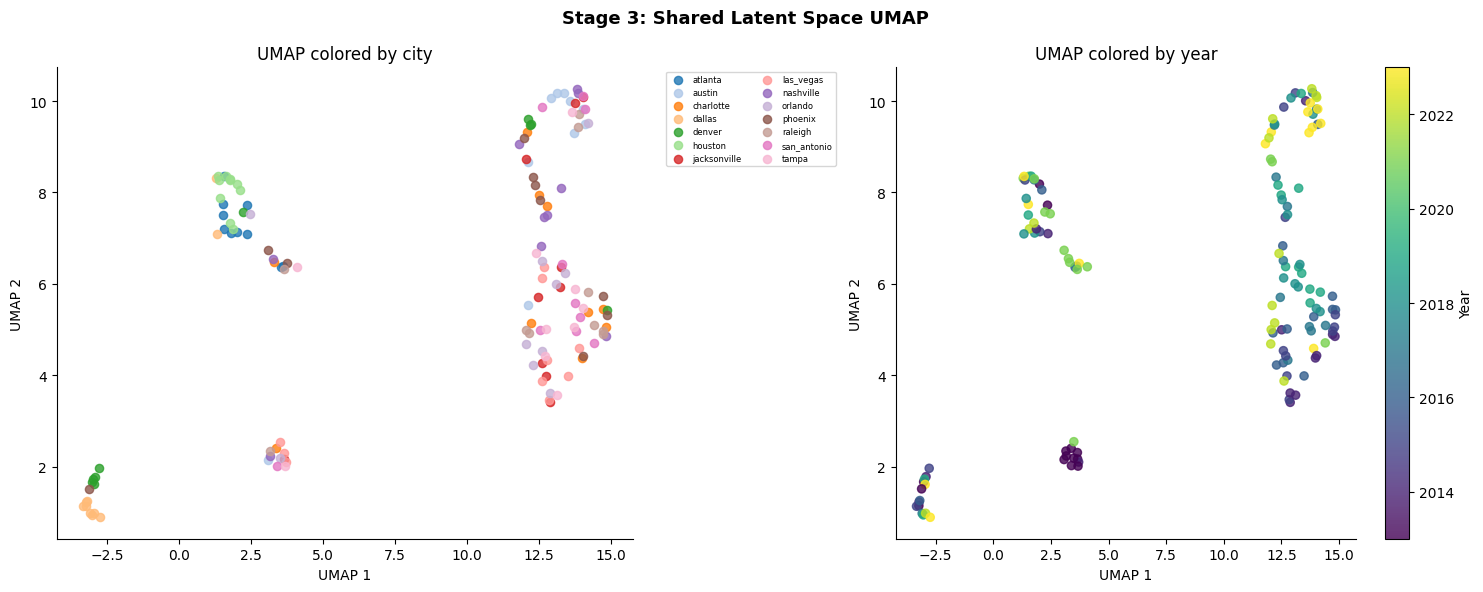

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

palette     = sns.color_palette("tab20", len(METROS))
metro_color = {m: palette[i] for i, m in enumerate(METROS)}

for metro in METROS:
    sub = latents_full[latents_full["metro"] == metro]
    axes[0].scatter(sub["umap1"], sub["umap2"],
                    color=metro_color[metro], s=35, alpha=0.8, label=metro)

axes[0].set_title("UMAP colored by city", fontsize=12)
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
axes[0].legend(fontsize=6, ncol=2,
               bbox_to_anchor=(1.05, 1), loc="upper left")
sns.despine(ax=axes[0])

norm = plt.Normalize(latents_full["year"].min(), latents_full["year"].max())
sc   = axes[1].scatter(latents_full["umap1"], latents_full["umap2"],
                        c=latents_full["year"], cmap="viridis",
                        s=35, alpha=0.8)
plt.colorbar(sc, ax=axes[1], label="Year")
axes[1].set_title("UMAP colored by year", fontsize=12)
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
sns.despine(ax=axes[1])

plt.suptitle("Stage 3: Shared Latent Space UMAP",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/09_umap_latent.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()

In [ ]:
from sklearn.metrics import pairwise_distances

Z_COLS = [c for c in latents_full.columns if c.startswith("z_")]
Z      = latents_full[Z_COLS].values
dists  = pairwise_distances(Z, metric="euclidean")

latents_econ_nn = latents_full.merge(
    econ_raw[["metro", "year", "gdp_millions_growth", "unemployment_rate"]],
    on=["metro", "year"], how="left"
)

query_city_years = [
    ("austin",    2021),
    ("phoenix",   2022),
    ("las_vegas", 2019),
    ("nashville", 2016),
]

print("Nearest neighbors in shared latent space z")
print("=" * 65)

for metro, year in query_city_years:
    mask = ((latents_econ_nn["metro"] == metro) &
            (latents_econ_nn["year"]  == year))
    if not mask.any():
        print(f"\n{metro} {year} — not found in latents")
        continue

    query_idx = mask.idxmax()
    dist_row  = dists[query_idx]
    nn_idx    = np.argsort(dist_row)[1:6]

    query_row = latents_econ_nn.loc[query_idx]
    print(f"\nQuery: {metro.title()} {year}  "
          f"GDP growth={query_row['gdp_millions_growth']:.1f}  "
          f"Unemployment={query_row['unemployment_rate']:.1f}%")
    print("-" * 65)
    print(f"  {'Neighbor':<22} {'Distance':>8}  {'GDP growth':>10}  {'Unemployment':>12}")

    for i in nn_idx:
        row = latents_econ_nn.iloc[i]
        print(f"  {row['metro'].title()+' '+str(row['year']):<22} "
              f"{dist_row[i]:>8.3f}  "
              f"{row['gdp_millions_growth']:>10.1f}  "
              f"{row['unemployment_rate']:>11.1f}%")

print("\n" + "=" * 65)

Nearest neighbors in shared latent space z

Query: Austin 2021  GDP growth=14.6  Unemployment=4.1%
-----------------------------------------------------------------
  Neighbor               Distance  GDP growth  Unemployment
  Jacksonville 2021         0.289         9.5          4.2%
  Phoenix 2017              0.349         4.6          4.3%
  Phoenix 2019              0.376         4.7          4.1%
  Phoenix 2022              0.416         5.4          3.3%
  Charlotte 2019            0.425         3.4          3.6%

Query: Phoenix 2022  GDP growth=5.4  Unemployment=3.3%
-----------------------------------------------------------------
  Neighbor               Distance  GDP growth  Unemployment
  Charlotte 2023            0.221         5.3          3.4%
  Nashville 2023            0.252         4.6          2.6%
  Jacksonville 2021         0.389         9.5          4.2%
  Denver 2017               0.406         3.9          2.5%
  Phoenix 2017              0.410         4.6        

---
## 7. Latent Space Evaluation and Economic Analogue Retrieval


In [36]:
IMG_SIZE = (512, 256)

vae.eval()
cnn_encoder.eval()

img_scaler_mean = torch.tensor(img_scaler.mean_, dtype=torch.float32).to(device)
img_scaler_std  = torch.tensor(np.sqrt(img_scaler.var_), dtype=torch.float32).to(device)

output_path = Path("data/img_only_z.csv")
if output_path.exists():
    output_path.unlink()

for metro in tqdm(METROS, desc="extracting image-only z"):
    metro_records = []

    with torch.no_grad():
        for year in MODIS_YEARS:
            modis_path = IMAGERY_DIR / metro / "modis_rgb"   / f"{year}.tif"
            viirs_path = IMAGERY_DIR / metro / "viirs_night" / f"{year}.tif"

            if not modis_path.exists():
                continue

            with rasterio.open(modis_path) as src:
                rgb = src.read().astype(np.float32) / 255.0

            target_h, target_w = rgb.shape[1], rgb.shape[2]

            if viirs_path.exists() and year >= min(VIIRS_YEARS):
                with rasterio.open(viirs_path) as src:
                    viirs_raw = src.read(1).astype(np.float32)
                nz = viirs_raw[viirs_raw > 0]
                if len(nz):
                    viirs_raw = np.clip(
                        (viirs_raw - np.percentile(nz,1)) /
                        (np.percentile(nz,99) - np.percentile(nz,1) + 1e-8),
                        0, 1)
                else:
                    viirs_raw = np.zeros_like(viirs_raw)
                viirs_t = torch.tensor(viirs_raw, dtype=torch.float32)
                if viirs_t.shape != (target_h, target_w):
                    viirs_t = F.interpolate(
                        viirs_t.unsqueeze(0).unsqueeze(0),
                        size=(target_h, target_w),
                        mode="bilinear", align_corners=False
                    ).squeeze()
            else:
                viirs_t = torch.zeros(target_h, target_w, dtype=torch.float32)

            rgb_t   = torch.tensor(rgb, dtype=torch.float32)
            img_t   = torch.cat([rgb_t, viirs_t.unsqueeze(0)], dim=0).unsqueeze(0)
            img_t   = F.interpolate(
                img_t, size=IMG_SIZE,
                mode="bilinear", align_corners=False
            ).to(device)

            raw_emb   = cnn_encoder.extract_embedding(img_t)
            raw_emb_s = (raw_emb - img_scaler_mean) / (img_scaler_std + 1e-8)

            z_img = vae.encode_img_only(raw_emb_s)
            z_np  = z_img.squeeze(0).cpu().float().numpy()

            rec = {"metro": metro, "year": year}
            for d in range(len(z_np)):
                rec[f"z_img_{d}"] = float(z_np[d])
            metro_records.append(rec)

    metro_df = pd.DataFrame(metro_records)
    metro_df.to_csv(
        output_path,
        mode="a",
        header=not output_path.exists() or output_path.stat().st_size == 0,
        index=False
    )
    del metro_records, metro_df

    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

final_df = pd.read_csv(output_path)
print(f"image-only z shape : {final_df.shape}")
print(f"metros complete    : {final_df['metro'].nunique()}")

extracting image-only z: 100%|██████████| 14/14 [01:00<00:00,  4.34s/it]

image-only z shape : (154, 18)
metros complete    : 14


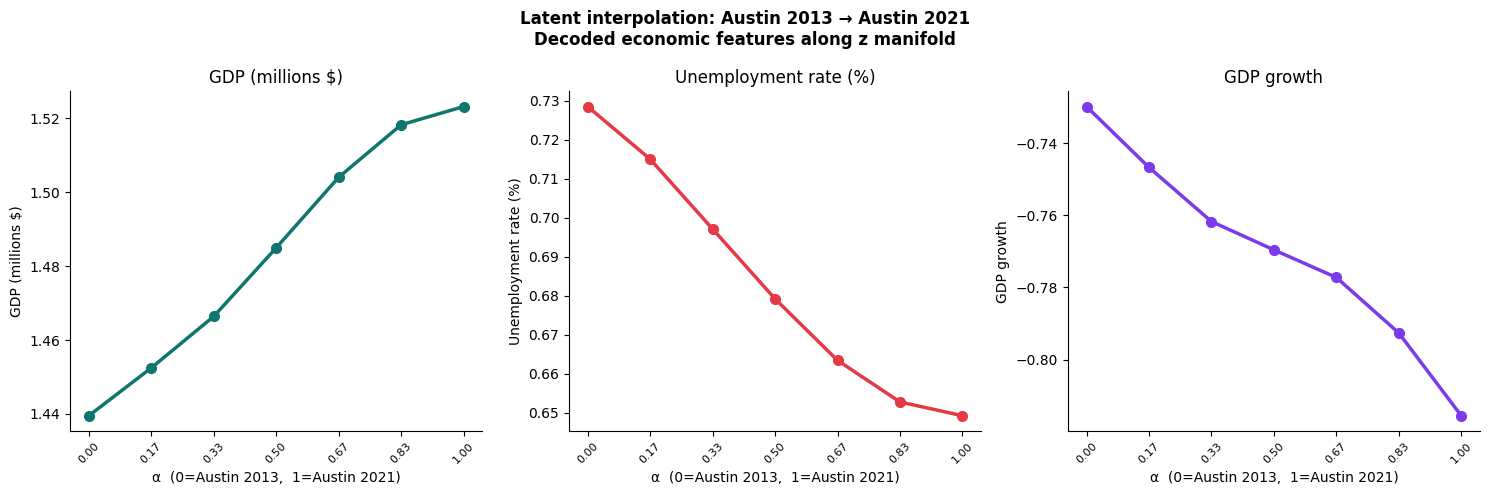

Decoded trajectory Austin 2013 → 2021:
  Step      α      GDP (M$)   Unemployment   GDP growth
  0      0.00           1.4           0.7%         -0.7
  1      0.17           1.5           0.7%         -0.7
  2      0.33           1.5           0.7%         -0.8
  3      0.50           1.5           0.7%         -0.8
  4      0.67           1.5           0.7%         -0.8
  5      0.83           1.5           0.7%         -0.8
  6      1.00           1.5           0.6%         -0.8


In [47]:
vae.eval()

city_a = ("austin", 2013)
city_b = ("austin", 2021)

latents_lookup = latents_full.set_index(["metro", "year"])
z_cols_interp  = [c for c in latents_full.columns if c.startswith("z_")]

z_a = torch.tensor(
    latents_lookup.loc[city_a, z_cols_interp].values.astype(np.float32),
    dtype=torch.float32).unsqueeze(0).to(device)

z_b = torch.tensor(
    latents_lookup.loc[city_b, z_cols_interp].values.astype(np.float32),
    dtype=torch.float32).unsqueeze(0).to(device)

econ_scaler_mean = torch.tensor(econ_scaler.mean_, dtype=torch.float32).to(device)
econ_scaler_std  = torch.tensor(np.sqrt(econ_scaler.var_), dtype=torch.float32).to(device)

steps      = 7
econ_feats = []

with torch.no_grad():
    for i in range(steps):
        alpha    = i / (steps - 1)
        z_interp = (1 - alpha) * z_a + alpha * z_b
        decoded  = vae.econ_decoder(z_interp)
        decoded_orig = (decoded * econ_scaler_std + econ_scaler_mean)
        econ_feats.append(decoded_orig.squeeze(0).cpu().float().numpy())

econ_feats = np.array(econ_feats)

gdp_idx    = ECON_FEATURES.index("gdp_millions")
unemp_idx  = ECON_FEATURES.index("unemployment_rate")
growth_idx = ECON_FEATURES.index("gdp_millions_growth")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, feat_idx, fname, color in [
    (axes[0], gdp_idx,    "GDP (millions $)",      "#0f766e"),
    (axes[1], unemp_idx,  "Unemployment rate (%)", "#e63946"),
    (axes[2], growth_idx, "GDP growth",            "#7c3aed"),
]:
    ax.plot(range(steps), econ_feats[:, feat_idx],
            marker="o", linewidth=2.5, color=color, markersize=7)
    ax.set_xticks(range(steps))
    ax.set_xticklabels(
        [f"{i/(steps-1):.2f}" for i in range(steps)],
        rotation=45, fontsize=8)
    ax.set_xlabel("α  (0=Austin 2013,  1=Austin 2021)")
    ax.set_ylabel(fname)
    ax.set_title(fname)
    sns.despine(ax=ax)

plt.suptitle("Latent interpolation: Austin 2013 → Austin 2021\n"
             "Decoded economic features along z manifold",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/14_latent_interpolation.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()

print("Decoded trajectory Austin 2013 → 2021:")
print(f"  {'Step':<5} {'α':>5}  {'GDP (M$)':>12}  "
      f"{'Unemployment':>13}  {'GDP growth':>11}")
for i, row in enumerate(econ_feats):
    alpha = i / (steps - 1)
    print(f"  {i:<5} {alpha:>5.2f}  "
          f"{row[gdp_idx]:>12.1f}  "
          f"{row[unemp_idx]:>12.1f}%  "
          f"{row[growth_idx]:>11.1f}")

In [45]:
from sklearn.metrics.pairwise import cosine_distances

dists_cos = cosine_distances(Z_query, Z_db)

print("Satellite-only economic analogue retrieval — cosine similarity")
print("Query: image-only z   Database: full joint z (training set)")
print("Metric: MAE on GDP growth (interpretable units, no regression model needed)")
print("=" * 60)
print(f"  {'Baseline':<30} MAE")
print(f"  {'Train mean':<30} {mae_mean_gdp:.3f}")
print(f"  {'Random retrieval (avg 100)':<30} {mae_rand_gdp:.3f}")
print(f"  {'Previous-year value':<30} {mae_py_gdp:.3f}")
print("-" * 60)

best_k, best_mae = None, float("inf")
for k in [1, 2, 3, 5]:
    gdp_preds = []
    for i in range(len(test_img_z)):
        q_gdp, _ = get_econ(test_img_z.iloc[i]["metro"],
                            int(test_img_z.iloc[i]["year"]))
        if q_gdp is None:
            continue
        nn_idx = np.argsort(dists_cos[i])[:k]
        vals   = []
        for ni in nn_idx:
            nr = train_full.iloc[ni]
            ng, _ = get_econ(nr["metro"], int(nr["year"]))
            if ng is not None:
                vals.append(ng)
        if vals:
            gdp_preds.append((q_gdp, np.mean(vals)))

    mae = np.mean([abs(a-b) for a,b in gdp_preds])
    if mae < best_mae:
        best_mae, best_k = mae, k
    print(f"  {'Cosine k='+str(k):<30} {mae:.3f}")

print("=" * 60)
print(f"  Best: cosine k={best_k}  MAE={best_mae:.3f}")
print()
print(f"  Improvement over train mean     : {mae_mean_gdp - best_mae:.3f}")
print(f"  Improvement over random         : {mae_rand_gdp - best_mae:.3f}")
print(f"  Improvement over previous-year  : {mae_py_gdp   - best_mae:.3f}")

Satellite-only economic analogue retrieval — cosine similarity
Query: image-only z   Database: full joint z (training set)
Metric: MAE on GDP growth (interpretable units, no regression model needed)
  Baseline                       MAE
  Train mean                     2.634
  Random retrieval (avg 100)     2.890
  Previous-year value            3.382
------------------------------------------------------------
  Cosine k=1                     1.925
  Cosine k=2                     1.953
  Cosine k=3                     1.994
  Cosine k=5                     1.949
  Best: cosine k=1  MAE=1.925

  Improvement over train mean     : 0.710
  Improvement over random         : 0.966
  Improvement over previous-year  : 1.457


In [47]:
def get_econ_col(metro, year, col):
    row = econ_raw[(econ_raw["metro"]==metro) & (econ_raw["year"]==year)]
    if row.empty or pd.isna(row[col].values[0]):
        return None
    return row[col].values[0]

def econ_all_col(col):
    return econ_raw[econ_raw["year"].isin(TRAIN_YEARS_VAE)][col].mean()

In [56]:
targets_new = {
    "gdp_millions_growth": "GDP growth",
    "employment_thousands_growth": "Employment growth",
    "total_permits_growth": "Permit growth",
    "gdp_per_employee": "GDP per employee",
    "permits_per_1k_emp": "Permits per 1k employees",
}

print("Satellite-only retrieval — cosine k=1 — additional targets")
print("=" * 65)
print(f"  {'Target':<28} {'Retrieval MAE':>14}  {'Train mean':>10}  {'Beats?':>6}")
print("-" * 65)

for col, label in targets_new.items():
    gdp_preds, mean_preds = [], []
    for i in range(len(test_img_z)):
        row   = test_img_z.iloc[i]
        q_val = get_econ_col(row["metro"], int(row["year"]), col)
        if q_val is None:
            continue
        ni    = np.argmin(dists_cos[i])
        nr    = train_full.iloc[ni]
        r_val = get_econ_col(nr["metro"], int(nr["year"]), col)
        tm_val = econ_all_col(col)
        if r_val is not None:
            gdp_preds.append((q_val, r_val))
            mean_preds.append((q_val, tm_val))

    mae_ret  = np.mean([abs(a-b) for a,b in gdp_preds])
    mae_mean = np.mean([abs(a-b) for a,b in mean_preds])
    beats    = "YES" if mae_ret < mae_mean else "NO"
    print(f"  {label:<28} {mae_ret:>14.3f}  {mae_mean:>10.3f}  {beats:>6}")

print("=" * 65)

Satellite-only retrieval — cosine k=1 — additional targets
  Target                        Retrieval MAE  Train mean  Beats?
-----------------------------------------------------------------
  GDP growth                            1.925       2.634     YES
  Employment growth                     2.717       2.214      NO
  Permit growth                        22.118      20.715      NO
  GDP per employee                     14.023      16.579     YES
  Permits per 1k employees              7.749       6.229      NO
